# 📦 Olist E-Commerce Data Analysis Project

Welcome! This notebook is built around the **Brazilian E-Commerce Public Dataset by Olist**.
Olist is a Brazilian marketplace that connects small businesses to major sales channels.
This dataset contains real (anonymized) orders made between 2016 and 2018.


### The Dataset Schema
The data is split across **9 CSV files**, connected to each other like this:

```
olist_order_payments_dataset ─── order_id ───┐
                                              │
olist_order_reviews_dataset ── order_id ── olist_orders_dataset ── order_id ── olist_order_items_dataset ── product_id ── olist_products_dataset
                                              │                                        │
                                        customer_id                              seller_id
                                              │                                        │
                                   olist_order_customer_dataset            olist_sellers_dataset
                                    (customers dataset)                              │
                                              │                                 zip_code_prefix
                                        zip_code_prefix                               │
                                              │                                 olist_geolocation_dataset
                                   olist_geolocation_dataset
```

**In plain words:**
- `olist_orders_dataset` is the **central table** — every order has one row here.
- Each order can have **multiple items** (`olist_order_items_dataset`), and each item belongs to one **product** and is sold by one **seller**.
- Each order has **one customer** (`olist_customers_dataset`), and customers/sellers can be located using **zip codes** which link to `olist_geolocation_dataset` (latitude/longitude).
- Each order can have **one or more payments** (`olist_order_payments_dataset`) — e.g., someone might split a payment across a voucher + credit card.
- Each order can have **one review** (`olist_order_reviews_dataset`) from the customer.
- `product_category_name_translation.csv` is just a lookup table to convert Portuguese category names into English.

## 🗺️ Project Roadmap

This notebook is being built for the **"ML Mini Project – Intelligent Business Analytics
& Forecasting System"** brief. Here's the full scope, so we always know where a given
section fits into the bigger picture:

| # | Pillar | What it means for us | Which Olist tables it mainly touches |
|---|--------|----------------------|----------------------------------------|
| 1 | **Predictive Modeling** (Classification + Regression) | Classification: e.g. predict something categorical, such as whether an order review will be positive/negative, or if a delivery will be late. Regression: predict a numeric value, such as delivery time or payment value. | `orders`, `order_items`, `payments`, `reviews` |
| 2 | **Customer Segmentation** (Clustering) | Group customers into segments based on behavior (e.g. spending, order frequency, location) using unsupervised learning — no target label needed. | `customers`, `orders`, `payments`, `order_items` |
| 3 | **NLP-based Review Analysis** | Work with the actual text in `review_comment_message` — things like sentiment analysis, text cleaning, and turning text into features (e.g. TF-IDF, word counts). | `reviews` |
| 4 | **Time-Series Sales Forecasting** | Aggregate orders over time (daily/weekly/monthly) and forecast future sales/order volume. | `orders`, `order_items` |

**Prerequisites this project assumes (per the brief):** Python, Pandas/NumPy, Matplotlib/Seaborn,
train/test splitting, the difference between supervised vs. unsupervised learning, and basic
scikit-learn usage. We already have the first three covered from Sections 1-4 above; the rest
will come up naturally as we build each pillar.

**A note on how we'll proceed:** Each pillar above will likely become its own set of sections
in this notebook (its own data prep, feature engineering, modeling, and evaluation steps) -
so don't worry if the notebook grows quite long. We'll add clear markdown headers before each
new pillar so it's always obvious which part of the project you're looking at.

## 1. Importing Libraries

Before doing anything, we import the tools we need:
- `pandas` → for loading and working with tabular data (our CSV files)
- `numpy` → for numerical operations
- `matplotlib` and `seaborn` → for plotting graphs and charts
- `warnings` → just to hide harmless warning messages so the notebook stays clean

In [7]:
# pandas is the main library we use to read CSVs and work with tables (called DataFrames)
import pandas as pd

# numpy helps with numerical operations (arrays, math functions, etc.)
import numpy as np

# matplotlib and seaborn are used for creating graphs/plots
import matplotlib.pyplot as plt
import seaborn as sns

# this hides unnecessary warning messages so our notebook output looks clean
import warnings
warnings.filterwarnings("ignore")

# this makes our plots appear directly inside the notebook
%matplotlib inline

# setting a nice default style for our plots
sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Loading the Datasets

There are 9 CSV files in total. We load each one into its own pandas DataFrame.
A DataFrame is just a table — think of it like an Excel sheet, but inside Python.

We keep the variable names close to the file names so it's easy to remember which
variable holds which data.

**Note on file paths:** `data_path` below is set to `""` (empty string), which means
"look for the CSV files in the same folder as this notebook". This matches the setup
where the notebook and all 9 CSVs sit together in one project folder
(e.g. `MiniProject/olist_project.ipynb` and `MiniProject/olist_customers_dataset.csv`).

If you ever organize your files differently — say, all CSVs inside a `data/` subfolder —
just change this one line to `data_path = "data/"` and every path below updates automatically.

In [8]:
# Folder where all our CSV files are stored.
# Empty string means "same folder as this notebook" — change this if your CSVs
# live somewhere else (e.g. "data/" if you keep them in a data subfolder).
data_path = ""

# Loading each CSV file into its own DataFrame (table)
customers_df   = pd.read_csv(data_path + "olist_customers_dataset.csv")
geolocation_df = pd.read_csv(data_path + "olist_geolocation_dataset.csv")
order_items_df = pd.read_csv(data_path + "olist_order_items_dataset.csv")
payments_df    = pd.read_csv(data_path + "olist_order_payments_dataset.csv")
reviews_df     = pd.read_csv(data_path + "olist_order_reviews_dataset.csv")
products_df    = pd.read_csv(data_path + "olist_products_dataset.csv")
sellers_df     = pd.read_csv(data_path + "olist_sellers_dataset.csv")
category_translation_df = pd.read_csv(data_path + "product_category_name_translation.csv")

# orders_df has several date columns (purchase date, delivery date, etc.).
# We tell pandas to parse them as real datetime objects right away (instead of
# plain text) using parse_dates — this makes date math (like "days between
# purchase and delivery") possible later without extra conversion steps.
date_columns = ["order_purchase_timestamp", "order_approved_at",
                "order_delivered_carrier_date", "order_delivered_customer_date",
                "order_estimated_delivery_date"]
orders_df = pd.read_csv(data_path + "olist_orders_dataset.csv", parse_dates=date_columns)

print("All 9 datasets loaded successfully!")

All 9 datasets loaded successfully!


## 3. First Look at Every Dataset

Before doing any analysis, it's important to get a feel for each table:
- **How many rows and columns does it have?**
- **What do the columns look like?**

We store all our DataFrames in a dictionary (a name -> table mapping) and loop
through them one by one. This way we don't have to repeat the same code 9 times.

In [9]:
# A dictionary that maps a readable name to its corresponding DataFrame
# This lets us loop through all datasets together instead of writing repetitive code
all_datasets = {
    "Customers": customers_df,
    "Geolocation": geolocation_df,
    "Order Items": order_items_df,
    "Payments": payments_df,
    "Reviews": reviews_df,
    "Orders": orders_df,
    "Products": products_df,
    "Sellers": sellers_df,
    "Category Translation": category_translation_df
}

# Looping through every dataset to print its shape (rows, columns)
for name in all_datasets:
    df = all_datasets[name]                      # get the current dataframe
    num_rows = df.shape[0]                        # number of rows
    num_cols = df.shape[1]                        # number of columns
    print(f"{name:22s} -> Rows: {num_rows:7,} | Columns: {num_cols}")

Customers              -> Rows:  99,441 | Columns: 5
Geolocation            -> Rows: 1,000,163 | Columns: 5
Order Items            -> Rows: 112,650 | Columns: 7
Payments               -> Rows: 103,886 | Columns: 5
Reviews                -> Rows:  99,224 | Columns: 7
Orders                 -> Rows:  99,441 | Columns: 8
Products               -> Rows:  32,951 | Columns: 9
Sellers                -> Rows:   3,095 | Columns: 4
Category Translation   -> Rows:      71 | Columns: 2


Let's now peek at the actual columns and a few sample rows from each dataset.
`.head()` shows the first 5 rows of a table so we can see what the data actually looks like.

In [10]:
# Looping through every dataset and displaying its first few rows
for name in all_datasets:
    df = all_datasets[name]
    print("=" * 80)
    print(f"Dataset: {name}")
    print("=" * 80)
    display(df.head())     # display() shows a nicely formatted table (works in Jupyter)
    print(df.shape)
    print()

Dataset: Customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


(99441, 5)

Dataset: Geolocation


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


(1000163, 5)

Dataset: Order Items


...

(32951, 9)

Dataset: Sellers


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


(3095, 4)

Dataset: Category Translation


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


(71, 2)



## 4. Checking Data Types and Missing Values

Two very common things we check early in any project:
1. **Data types** — e.g., is a date column actually being read as text (`object`) instead of a proper date?
2. **Missing values** — are there empty/NaN cells that we'll need to handle later?

We loop through each dataset again and print a quick missing-value summary.

In [23]:
# Looping through every dataset to check for missing values
for name in all_datasets:
    df = all_datasets[name]
    missing_counts = df.isnull().sum()              # count of missing values per column
    missing_counts = missing_counts[missing_counts > 0]  # keep only columns that DO have missing values

    print("=" * 80)
    print(f"Dataset: {name}")
    if len(missing_counts) == 0:
        print("No missing values found.")
    else:
        print("Missing values found in these columns:")
        print(missing_counts)
    print()

Dataset: Customers
No missing values found.

Dataset: Geolocation
No missing values found.

Dataset: Order Items
No missing values found.

Dataset: Payments
No missing values found.

Dataset: Reviews
Missing values found in these columns:
review_comment_title      87656
review_comment_message    58247
dtype: int64

Dataset: Orders
Missing values found in these columns:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Dataset: Products
Missing values found in these columns:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Dataset: Sellers
No missing values found.

Dataset: Category Translation
No missing values found.



# 🎯 Module: Supervised Learning — Predictive Modeling

This module covers **Pillar 1** from our roadmap: building a Regression model and a
Classification model on top of the Olist data.

### A quick design decision, explained upfront

The project brief asks for a Regression model and a Classification model, but doesn't say
*what exactly* to predict. Rather than guess randomly, here's what we picked and why:

- **Regression target → `delivery_time_days`**: how many days it actually takes for an
  order to reach the customer, counted from the purchase timestamp. This is a genuinely
  useful business number (logistics planning, customer expectations) and it's a clean
  continuous variable — a good fit for regression.
- **Classification target → `is_late`**: whether the order arrived *after* the
  estimated delivery date Olist promised the customer (1 = late, 0 = on time / early).
  This is a natural yes/no business question ("will this shipment be late?") — a good
  fit for classification.

Both targets are about delivery performance, which lets us reuse **one shared feature set**
for both tasks, but each model answers a different kind of question (a number vs. a yes/no).

**Important rule we follow to avoid "cheating":** our features can only be things we'd
actually know *at the time the order is placed* — product details, price, freight, payment
info, customer/seller location, and the *promised* delivery date (`estimated_time_days`,
which Olist calculates upfront). We deliberately do **not** let `delivery_time_days` sneak
in as a feature for predicting `is_late` (and vice versa) — since one is almost directly
computed from the other, that would be **data leakage**: the model would appear to perform
great by cheating, but would be useless in the real world where the actual delivery date
isn't known yet.

## 5.1 Building the Order-Level Master Dataset

Our tables are spread across different granularities:
- `orders_df` → one row per **order**
- `order_items_df` → one row per **item within an order** (an order can have several items,
  possibly from different sellers)
- `payments_df` → one row per **payment** (an order can be paid in more than one transaction)

To build a model, we need **one row per order**. So the first job is to squash the
item-level and payment-level tables down to the order level, and then merge everything
together onto `orders_df`.

**Step 1: Keep only delivered orders with a known delivery date.**
Our targets (`delivery_time_days`, `is_late`) both depend on knowing when the order was
actually delivered — so orders that are still in transit, canceled, or missing that date
simply can't be used for training.

In [24]:
# Keep only orders that were actually delivered, and that have a real delivery date
# (a tiny number of "delivered" orders are still missing this date due to data entry gaps)
delivered_mask = (orders_df["order_status"] == "delivered") & (orders_df["order_delivered_customer_date"].notnull())
master_df = orders_df[delivered_mask].copy()

print(f"Orders before filtering : {len(orders_df):,}")
print(f"Orders after filtering  : {len(master_df):,}")

Orders before filtering : 99,441
Orders after filtering  : 96,470


**Step 2: Squash `order_items_df` down to one row per order.**

For every order, we compute:
- `num_items` → how many items were in the order
- `total_price` → sum of item prices
- `total_freight` → sum of shipping/freight charges

We also need **one representative product and seller per order** (since an order can mix
multiple products/sellers). We pick the item with the **highest price** as the "main item"
of the order — a simple, reasonable rule of thumb — and take its product category,
weight, and volume, plus its seller's state.

In [25]:
# Bring English category names into the items table (the raw categories are in Portuguese)
items_with_products = order_items_df.merge(products_df, on="product_id", how="left")
items_with_products = items_with_products.merge(category_translation_df, on="product_category_name", how="left")

# A derived feature: product volume in cubic cm (length x height x width)
# This is a "derived feature" in the feature-engineering sense — it's not a raw column,
# we're combining 3 existing columns into a new, more meaningful one.
items_with_products["product_volume_cm3"] = (
    items_with_products["product_length_cm"]
    * items_with_products["product_height_cm"]
    * items_with_products["product_width_cm"]
)

# For each order, find the row (item) with the highest price -> treat it as the "main" item
main_item_index = items_with_products.groupby("order_id")["price"].idxmax()
main_item_info = items_with_products.loc[main_item_index, [
    "order_id", "seller_id", "product_category_name_english",
    "product_weight_g", "product_volume_cm3"
]]
main_item_info = main_item_info.rename(columns={"product_category_name_english": "main_category"})

# Now compute the order-level aggregates: item count, total price, total freight
order_item_summary = order_items_df.groupby("order_id").agg(
    num_items=("order_item_id", "count"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum")
).reset_index()

# Attach the "main item" info (category, weight, volume, seller) to the order-level summary
order_item_summary = order_item_summary.merge(main_item_info, on="order_id", how="left")

# Attach the seller's state using the seller_id we just picked
order_item_summary = order_item_summary.merge(
    sellers_df[["seller_id", "seller_state"]], on="seller_id", how="left"
)

print("Order-item summary shape:", order_item_summary.shape)
order_item_summary.head()

Order-item summary shape: (98666, 9)


,order_id,num_items,total_price,total_freight,seller_id,main_category,product_weight_g,product_volume_cm3,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,48436dade18ac8b2bce089ec2a041202,cool_stuff,650.0,3528.0,SP
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,dd7ddc04e1b6c2c614352b383efe2d36,pet_shop,30000.0,60000.0,SP
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,5b51032eddd242adc84c38acab88f23d,furniture_decor,3050.0,14157.0,MG
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,9d7a1d34a5052409006425275ba1c2b4,perfumery,200.0,2400.0,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,df560393f3a51e74553ab94004ba5c87,garden_tools,3750.0,42000.0,PR


**Step 3: Squash `payments_df` down to one row per order.**

For every order, we compute:
- `total_payment_value` → sum of all payment transactions for that order
- `payment_installments` → the maximum number of installments used
- `payment_type` → the most frequently used payment method for that order
  (most orders only have one payment type, but a few are split across methods)

In [26]:
# Most common payment_type per order (in case an order has more than one payment row)
most_common_payment_type = (
    payments_df.groupby("order_id")["payment_type"]
    .agg(lambda values: values.value_counts().idxmax())
    .reset_index()
)

# Sum up payment amounts and take the highest installment count per order
payment_summary = payments_df.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    payment_installments=("payment_installments", "max")
).reset_index()

# Attach the payment type we computed above
payment_summary = payment_summary.merge(most_common_payment_type, on="order_id", how="left")

print("Payment summary shape:", payment_summary.shape)
payment_summary.head()

Payment summary shape: (99440, 4)


,order_id,total_payment_value,payment_installments,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


**Step 4: Bring everything together onto `master_df`.**

Now that `order_item_summary` and `payment_summary` are both one-row-per-order, we can
merge them (and the customer's state) straight onto our filtered orders table.

In [27]:
# Bring in the customer's state (needed as a feature later)
master_df = master_df.merge(customers_df[["customer_id", "customer_state"]], on="customer_id", how="left")

# Bring in the item-level and payment-level summaries we just built
master_df = master_df.merge(order_item_summary, on="order_id", how="left")
master_df = master_df.merge(payment_summary, on="order_id", how="left")

print("Master dataset shape:", master_df.shape)
master_df.head()

Master dataset shape: (96470, 20)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,num_items,total_price,total_freight,seller_id,main_category,product_weight_g,product_volume_cm3,seller_state,total_payment_value,payment_installments,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,SP,1,29.99,8.72,3504c0cb71d7fa48d967e0e4c94d59d9,housewares,500.0,1976.0,SP,38.71,1.0,voucher
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,BA,1,118.70,22.76,289cdb325fb7e7f891c38608bf9e0962,perfumery,400.0,4693.0,SP,141.46,1.0,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,GO,1,159.90,19.22,4869f7a5dfa277a7dca6462dcf3b52b2,auto,420.0,9576.0,SP,179.12,3.0,credit_card
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,RN,1,45.00,27.20,66922902710d126a0e7d26b0e3805106,pet_shop,450.0,6000.0,MG,72.20,1.0,credit_card
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,SP,1,19.90,8.72,2c9e548be18521d1c43cde1c582c6de8,stationery,250.0,11475.0,SP,28.62,1.0,credit_card


## 5.2 Creating the Target Variables and Time-Based Features

Now we compute the actual columns we'll predict, plus a couple of useful time-based
features derived from the purchase timestamp:

- `purchase_month` and `purchase_dayofweek` — captures seasonality/weekly patterns
  (e.g. maybe orders placed in December take longer due to holiday volume)
- `estimated_time_days` — how many days Olist *promised* for delivery (known at order time)
- `delivery_time_days` — how many days delivery *actually* took → **our regression target**
- `is_late` — 1 if the order arrived after the promised date, else 0 → **our classification target**

In [28]:
# Time-based derived features from the purchase timestamp
master_df["purchase_month"] = master_df["order_purchase_timestamp"].dt.month
master_df["purchase_dayofweek"] = master_df["order_purchase_timestamp"].dt.dayofweek  # 0 = Monday

# REGRESSION TARGET: how many days delivery actually took
master_df["delivery_time_days"] = (
    master_df["order_delivered_customer_date"] - master_df["order_purchase_timestamp"]
).dt.days

# A feature we're allowed to use (known at order time): how many days Olist promised
master_df["estimated_time_days"] = (
    master_df["order_estimated_delivery_date"] - master_df["order_purchase_timestamp"]
).dt.days

# CLASSIFICATION TARGET: did the order arrive later than promised?
master_df["is_late"] = (
    master_df["order_delivered_customer_date"] > master_df["order_estimated_delivery_date"]
).astype(int)

print("Delivery time (days) summary:")
print(master_df["delivery_time_days"].describe())

print()
print("is_late distribution (fraction of orders):")
print(master_df["is_late"].value_counts(normalize=True))

Delivery time (days) summary:
count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time_days, dtype: float64

is_late distribution (fraction of orders):
is_late
0    0.918876
1    0.081124
Name: proportion, dtype: float64


**Something worth noticing:** only about **8%** of orders arrive late. This is a classic
**imbalanced classification problem** — a model could look 92% "accurate" just by always
predicting "not late" while being completely useless in practice. Keep this in mind when we
get to evaluating the classification models later — accuracy alone will be a misleading
metric here, so we'll lean on **precision, recall, F1, and ROC-AUC** to judge things fairly.

## 5.3 Handling Missing Values

A few columns pick up small amounts of missing data from the merges above (e.g. some
products in the catalog are missing a category, weight, or dimensions). We fix each one
with a sensible, explainable rule:

| Column | Missing reason | How we fill it |
|---|---|---|
| `main_category` | Product had no category listed, or category had no English translation | Fill with `"unknown"` |
| `product_weight_g`, `product_volume_cm3` | A handful of products are missing physical dimensions | Fill with the **median** (robust to outliers) |
| `total_payment_value` | Extremely rare edge case where payment data didn't join | Fill with `total_price + total_freight` as a reasonable stand-in |
| `payment_installments` | Same rare edge case | Fill with `1` (a single, non-installment payment) |
| `payment_type` | Same rare edge case | Fill with `"unknown"` |

In [29]:
print(master_df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_state', 'num_items', 'total_price', 'total_freight', 'seller_id', 'main_category', 'product_weight_g', 'product_volume_cm3', 'seller_state', 'total_payment_value', 'payment_installments', 'payment_type', 'purchase_month', 'purchase_dayofweek', 'delivery_time_days', 'estimated_time_days', 'is_late']


In [30]:
# Check how much missing data we're actually dealing with before fixing it
columns_to_check = ["main_category", "product_weight_g", "product_volume_cm3",
                     "total_payment_value", "payment_installments", "payment_type"]
print("Missing values before cleaning:")
print(master_df[columns_to_check].isnull().sum())

Missing values before cleaning:
main_category           1378
product_weight_g          16
product_volume_cm3        16
total_payment_value        1
payment_installments       1
payment_type               1
dtype: int64


In [31]:
# Now apply the fixes described in the table above
master_df["main_category"] = master_df["main_category"].fillna("unknown")
master_df["product_weight_g"] = master_df["product_weight_g"].fillna(master_df["product_weight_g"].median())
master_df["product_volume_cm3"] = master_df["product_volume_cm3"].fillna(master_df["product_volume_cm3"].median())
master_df["total_payment_value"] = master_df["total_payment_value"].fillna(master_df["total_price"] + master_df["total_freight"])
master_df["payment_installments"] = master_df["payment_installments"].fillna(1)
master_df["payment_type"] = master_df["payment_type"].fillna("unknown")

print("Missing values after cleaning:")
print(master_df[columns_to_check].isnull().sum())

Missing values after cleaning:
main_category           0
product_weight_g        0
product_volume_cm3      0
total_payment_value     0
payment_installments    0
payment_type            0
dtype: int64


## 5.4 Feature Engineering: Category Bucketing + One-Hot Encoding

`main_category` has around **70 different values**, and many of them are rare (only a
handful of orders each). One-hot encoding all 70 would create a huge number of columns
for very little benefit. So first we **bucket rare categories**: keep the top 15 most
common categories as-is, and lump everything else into a single `"other"` bucket.

Then we **one-hot encode** our categorical columns — `main_category_bucketed`,
`customer_state`, `seller_state`, and `payment_type` — turning each category into its own
0/1 column, since ML models need numbers, not text labels.

In [32]:
# Keep only the 15 most frequent categories; bucket everything else as "other"
top_15_categories = master_df["main_category"].value_counts().nlargest(15).index

master_df["main_category_bucketed"] = master_df["main_category"].apply(
    lambda category: category if category in top_15_categories else "other"
)

print("Category counts after bucketing:")
print(master_df["main_category_bucketed"].value_counts())

Category counts after bucketing:
main_category_bucketed
other                    20412
bed_bath_table            9184
health_beauty             8613
sports_leisure            7492
computers_accessories     6511
furniture_decor           6188
housewares                5680
watches_gifts             5476
telephony                 4073
auto                      3792
toys                      3787
cool_stuff                3530
garden_tools              3400
perfumery                 3069
baby                      2761
electronics               2502
Name: count, dtype: int64


In [33]:
# One-hot encode all our categorical columns.
# drop_first=True drops one column per category group to avoid redundant/duplicate information
# (this is standard practice called "avoiding the dummy variable trap")
categorical_columns = ["main_category_bucketed", "customer_state", "seller_state", "payment_type"]
encoded_categorical = pd.get_dummies(master_df[categorical_columns], drop_first=True)

print("Shape before encoding:", master_df[categorical_columns].shape)
print("Shape after encoding :", encoded_categorical.shape)
encoded_categorical.head()

Shape before encoding: (96470, 4)
Shape after encoding : (96470, 66)


,main_category_bucketed_baby,main_category_bucketed_bed_bath_table,main_category_bucketed_computers_accessories,main_category_bucketed_cool_stuff,main_category_bucketed_electronics,main_category_bucketed_furniture_decor,main_category_bucketed_garden_tools,main_category_bucketed_health_beauty,main_category_bucketed_housewares,main_category_bucketed_other,...,seller_state_RN,seller_state_RO,seller_state_RS,seller_state_SC,seller_state_SE,seller_state_SP,payment_type_credit_card,payment_type_debit_card,payment_type_unknown,payment_type_voucher
0,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,True,True,False,False,False


## 5.5 Assembling the Final Feature Matrix

Time to put together our `X` (features) and two separate `y` targets:
- `y_reg` = `delivery_time_days` (for regression)
- `y_clf` = `is_late` (for classification)

Both models share the **same `X`** — same features, different questions being asked of them.

In [34]:
# Numeric columns we'll use as features directly
numeric_features = [
    "num_items", "total_price", "total_freight", "product_weight_g", "product_volume_cm3",
    "total_payment_value", "payment_installments", "purchase_month", "purchase_dayofweek",
    "estimated_time_days"
]

# Combine numeric features with the one-hot encoded categorical features from Section 5.4
X = pd.concat([master_df[numeric_features], encoded_categorical], axis=1)

# Our two targets
y_reg = master_df["delivery_time_days"]   # regression target
y_clf = master_df["is_late"]              # classification target

print("Final feature matrix shape:", X.shape)
print("Regression target shape   :", y_reg.shape)
print("Classification target shape:", y_clf.shape)

Final feature matrix shape: (96470, 76)
Regression target shape   : (96470,)
Classification target shape: (96470,)


## 5.6 Train/Test Split

We split our data into a **training set** (80%) and a **test set** (20%). Models learn
patterns from the training set, and we judge them on the test set — data they've never
seen — to get an honest estimate of how they'd perform on new, real orders.

We split `X`, `y_reg`, and `y_clf` **together** in one call so the same rows end up in the
same train/test groups for both tasks (keeps things consistent and simple).

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.2,      # 20% of the data held out for testing
    random_state=42     # fixed seed so the split is reproducible every time we run this
)

print("Training rows:", X_train.shape[0])
print("Test rows    :", X_test.shape[0])

Training rows: 77176
Test rows    : 19294


## 5.7 Feature Scaling (Standardization)

Our numeric features live on very different scales — e.g. `total_price` might range in the
hundreds, while `payment_installments` ranges from 1 to about 24. Some models (like Linear
Regression, Logistic Regression, and KNN) are sensitive to this and can be biased toward
large-scale columns. **Standardization** rescales each numeric column to have mean 0 and
standard deviation 1, putting them all on equal footing.

**Important rule:** we `fit` the scaler only on the **training data**, then use that same
fitted scaler to `transform` the test data. If we fit on the full dataset (train + test),
information from the test set would "leak" into training — another form of data leakage.

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Work on copies so we don't overwrite our original train/test splits
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# fit_transform learns the mean/std from TRAINING data only, and scales it
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])

# transform (no fit!) applies the SAME training-set mean/std to the test data
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("Scaling done. Example — 'total_price' before vs after scaling (training set):")
print("Before:", X_train["total_price"].head(3).values)
print("After :", X_train_scaled["total_price"].head(3).values)

Scaling done. Example — 'total_price' before vs after scaling (training set):
Before: [ 19.99 117.99 119.89]
After : [-0.55404815 -0.09229991 -0.08334765]


## 5.8 Feature Selection

Our feature matrix has around 75 columns (mostly from one-hot encoding all those states and
categories). Not all of them are equally useful. We use `SelectKBest` from scikit-learn to
automatically keep only the **top 30 most statistically relevant features** for each target:

- For regression (`y_reg`), we score features using `f_regression`
- For classification (`y_clf`), we score features using `f_classif`

Since regression and classification are different questions, they can end up favoring
slightly different features — which is exactly why we run feature selection separately
for each one.

In [37]:
from sklearn.feature_selection import SelectKBest, f_regression, f_classif

NUM_FEATURES_TO_KEEP = 30

# --- Feature selection for the regression task ---
regression_selector = SelectKBest(score_func=f_regression, k=NUM_FEATURES_TO_KEEP)
regression_selector.fit(X_train_scaled, y_reg_train)          # learn which features matter, using TRAIN data only
regression_selected_columns = X_train_scaled.columns[regression_selector.get_support()]

# --- Feature selection for the classification task ---
classification_selector = SelectKBest(score_func=f_classif, k=NUM_FEATURES_TO_KEEP)
classification_selector.fit(X_train_scaled, y_clf_train)
classification_selected_columns = X_train_scaled.columns[classification_selector.get_support()]

print(f"Selected {len(regression_selected_columns)} features for REGRESSION:")
print(list(regression_selected_columns))
print()
print(f"Selected {len(classification_selected_columns)} features for CLASSIFICATION:")
print(list(classification_selected_columns))

Selected 30 features for REGRESSION:
['total_price', 'total_freight', 'product_weight_g', 'product_volume_cm3', 'total_payment_value', 'payment_installments', 'purchase_month', 'estimated_time_days', 'main_category_bucketed_housewares', 'customer_state_AL', 'customer_state_AM', 'customer_state_AP', 'customer_state_BA', 'customer_state_CE', 'customer_state_ES', 'customer_state_GO', 'customer_state_MA', 'customer_state_MT', 'customer_state_PA', 'customer_state_PB', 'customer_state_PE', 'customer_state_PI', 'customer_state_RJ', 'customer_state_RN', 'customer_state_RO', 'customer_state_RS', 'customer_state_SC', 'customer_state_SE', 'customer_state_SP', 'payment_type_credit_card']

Selected 30 features for CLASSIFICATION:
['num_items', 'total_price', 'total_freight', 'product_weight_g', 'product_volume_cm3', 'total_payment_value', 'purchase_month', 'purchase_dayofweek', 'estimated_time_days', 'main_category_bucketed_electronics', 'customer_state_AL', 'customer_state_BA', 'customer_state_CE'

In [38]:
# Build the final, feature-selected train/test sets for each task
X_train_reg = X_train_scaled[regression_selected_columns]
X_test_reg = X_test_scaled[regression_selected_columns]

X_train_clf = X_train_scaled[classification_selected_columns]
X_test_clf = X_test_scaled[classification_selected_columns]

print("Regression feature sets     :", X_train_reg.shape, X_test_reg.shape)
print("Classification feature sets :", X_train_clf.shape, X_test_clf.shape)

Regression feature sets     : (77176, 30) (19294, 30)
Classification feature sets : (77176, 30) (19294, 30)


## 5.9 Regression Models: Training & Evaluation

We train **4 regression models** to predict `delivery_time_days`:
- **Linear Regression** — the simplest baseline, fits a straight-line relationship
- **Ridge Regression** — Linear Regression + a penalty that shrinks large coefficients (helps with overfitting)
- **Lasso Regression** — like Ridge, but can shrink some coefficients all the way to zero (acts like automatic feature selection)
- **Random Forest Regressor** — an ensemble of decision trees, can capture non-linear patterns

We judge each model using 3 standard regression metrics:
- **MAE (Mean Absolute Error)** — average error in days, easy to interpret directly
- **RMSE (Root Mean Squared Error)** — like MAE but penalizes big mistakes more heavily
- **R² (R-squared)** — how much of the variation in delivery time our model explains (1.0 = perfect, 0 = no better than guessing the average)

In [39]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# A small helper function so we don't repeat the same training/evaluation code 4 times
def train_and_evaluate_regressor(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)                 # train the model
    predictions = model.predict(X_test)          # predict on unseen test data

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    return mae, rmse, r2, model

# Dictionary of the 4 regression models we want to compare
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Loop through each model, train it, evaluate it, and store the results
regression_results = []
trained_regression_models = {}

for model_name in regression_models:
    model = regression_models[model_name]
    mae, rmse, r2, trained_model = train_and_evaluate_regressor(
        model, X_train_reg, y_reg_train, X_test_reg, y_reg_test
    )
    regression_results.append([model_name, mae, rmse, r2])
    trained_regression_models[model_name] = trained_model
    print(f"{model_name:25s} -> MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f}")

Linear Regression         -> MAE: 5.293 | RMSE: 8.171 | R2: 0.231
Ridge Regression          -> MAE: 5.293 | RMSE: 8.170 | R2: 0.231
Lasso Regression          -> MAE: 5.414 | RMSE: 8.335 | R2: 0.199
Random Forest Regressor   -> MAE: 5.000 | RMSE: 7.933 | R2: 0.275


### Regression Model Comparison Table (Deliverable)

In [40]:
# Build a clean comparison table out of our results list
regression_comparison_df = pd.DataFrame(
    regression_results, columns=["Model", "MAE", "RMSE", "R2"]
).sort_values("R2", ascending=False).reset_index(drop=True)

# Highlight the best model per metric (lowest MAE/RMSE, highest R2) for a quick visual read
regression_comparison_df.style.highlight_min(subset=["MAE", "RMSE"], color="lightgreen")\
                               .highlight_max(subset=["R2"], color="lightgreen")

,Model,MAE,RMSE,R2
0,Random Forest Regressor,4.999703,7.933166,0.274691
1,Ridge Regression,5.292704,8.170341,0.230674
2,Linear Regression,5.293126,8.170735,0.230600
3,Lasso Regression,5.414405,8.334584,0.199433


## 5.10 Classification Models: Training & Evaluation

We train **4 classification models** to predict `is_late`:
- **Logistic Regression** — a simple, interpretable linear baseline for classification
- **Decision Tree** — splits data into yes/no rules, easy to visualize/interpret
- **Random Forest** — an ensemble of many decision trees, usually more accurate and stable
- **KNN (K-Nearest Neighbors)** — classifies an order based on the "closest" similar orders

Since we found earlier that only ~8% of orders are late (an **imbalanced** target), we pass
`class_weight="balanced"` to the models that support it — this tells the model to pay
extra attention to the minority ("late") class instead of ignoring it in favor of the easy,
majority ("on-time") class.

We judge each model using 5 metrics:
- **Accuracy** — overall % correct (can be misleading here, see note above)
- **Precision** — of the orders we predicted "late", how many actually were late?
- **Recall** — of the orders that were actually late, how many did we catch?
- **F1 Score** — the balance between precision and recall
- **ROC-AUC** — how well the model ranks late orders as riskier than on-time ones, across all thresholds

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)

# A small helper function so we don't repeat the same training/evaluation code 4 times
def train_and_evaluate_classifier(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # predict_proba gives us probability scores, needed for ROC-AUC
    # (KNN and the others all support this; we fall back to hard predictions just in case)
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test)[:, 1]
    else:
        probabilities = predictions

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)
    auc = roc_auc_score(y_test, probabilities)
    cm = confusion_matrix(y_test, predictions)

    return accuracy, precision, recall, f1, auc, cm, model

# Dictionary of the 4 classification models we want to compare
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=5)   # KNN has no class_weight option
}

# Loop through each model, train it, evaluate it, and store the results
classification_results = []
trained_classification_models = {}
confusion_matrices = {}

for model_name in classification_models:
    model = classification_models[model_name]
    accuracy, precision, recall, f1, auc, cm, trained_model = train_and_evaluate_classifier(
        model, X_train_clf, y_clf_train, X_test_clf, y_clf_test
    )
    classification_results.append([model_name, accuracy, precision, recall, f1, auc])
    trained_classification_models[model_name] = trained_model
    confusion_matrices[model_name] = cm
    print(f"{model_name:22s} -> Accuracy: {accuracy:.3f} | Precision: {precision:.3f} | "
          f"Recall: {recall:.3f} | F1: {f1:.3f} | ROC-AUC: {auc:.3f}")

Logistic Regression    -> Accuracy: 0.631 | Precision: 0.131 | Recall: 0.646 | F1: 0.217 | ROC-AUC: 0.688
Decision Tree          -> Accuracy: 0.873 | Precision: 0.200 | Recall: 0.200 | F1: 0.200 | ROC-AUC: 0.565
Random Forest          -> Accuracy: 0.907 | Precision: 0.352 | Recall: 0.202 | F1: 0.257 | ROC-AUC: 0.756
KNN                    -> Accuracy: 0.914 | Precision: 0.344 | Recall: 0.085 | F1: 0.136 | ROC-AUC: 0.651


### Classification Model Comparison Table (Deliverable)

In [42]:
classification_comparison_df = pd.DataFrame(
    classification_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)

classification_comparison_df.style.highlight_max(
    subset=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"], color="lightgreen"
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.907121,0.352273,0.202350,0.257048,0.756475
1,Logistic Regression,0.630766,0.130647,0.645561,0.217315,0.687879
2,KNN,0.914481,0.343915,0.084856,0.136126,0.650804
3,Decision Tree,0.872862,0.199609,0.199739,0.199674,0.565295


### Confusion Matrices

A confusion matrix shows exactly *where* each model's predictions went right or wrong:
- **Top-left** = correctly predicted "on time"
- **Bottom-right** = correctly predicted "late" (the harder, rarer case)
- **Off-diagonal cells** = mistakes

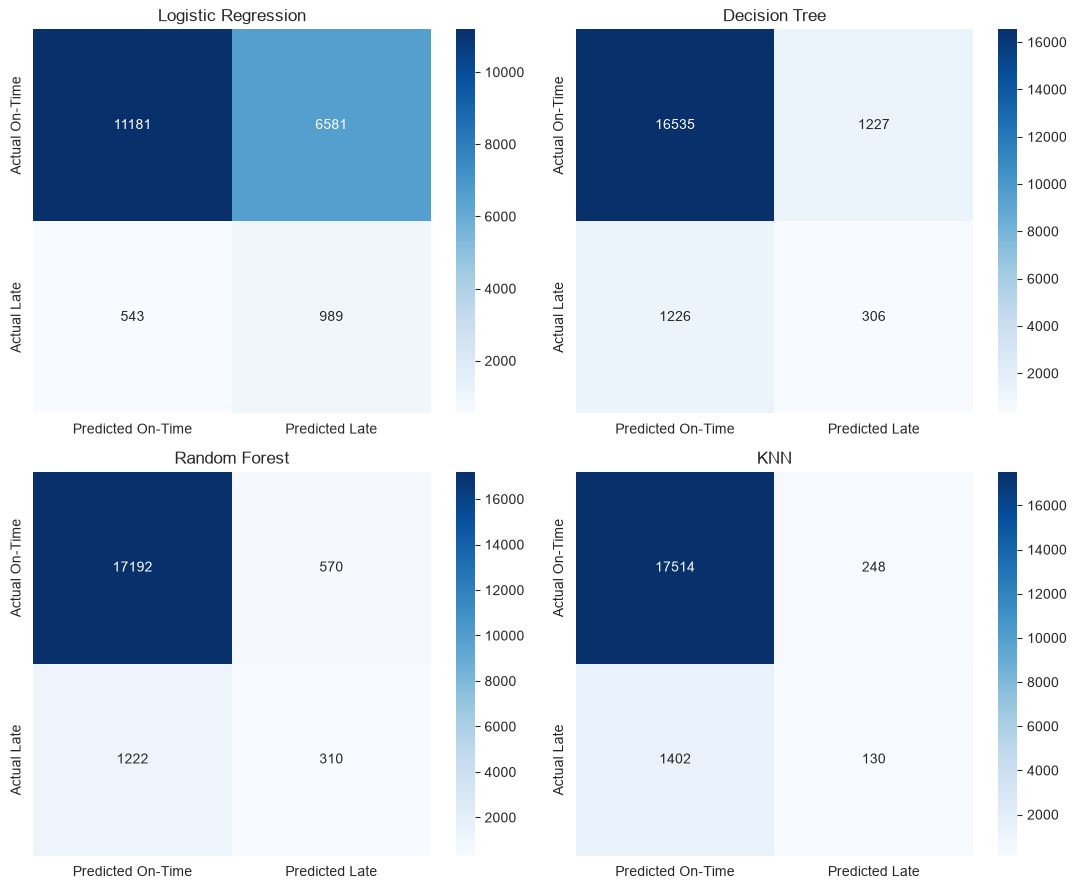

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()  # turn the 2x2 grid of axes into a simple list of 4

for i, model_name in enumerate(confusion_matrices):
    cm = confusion_matrices[model_name]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["Predicted On-Time", "Predicted Late"],
                yticklabels=["Actual On-Time", "Actual Late"])
    axes[i].set_title(model_name)

plt.tight_layout()
plt.show()

## 5.11 Feature Importance Visualization (Deliverable)

Tree-based models (Random Forest) can tell us which features they leaned on most heavily
via `.feature_importances_`. This is great for explaining a model's decisions to a
non-technical audience — e.g. "delivery time is mostly driven by X and Y."

We plot the top 10 most important features for both our Random Forest Regressor and
Random Forest Classifier.

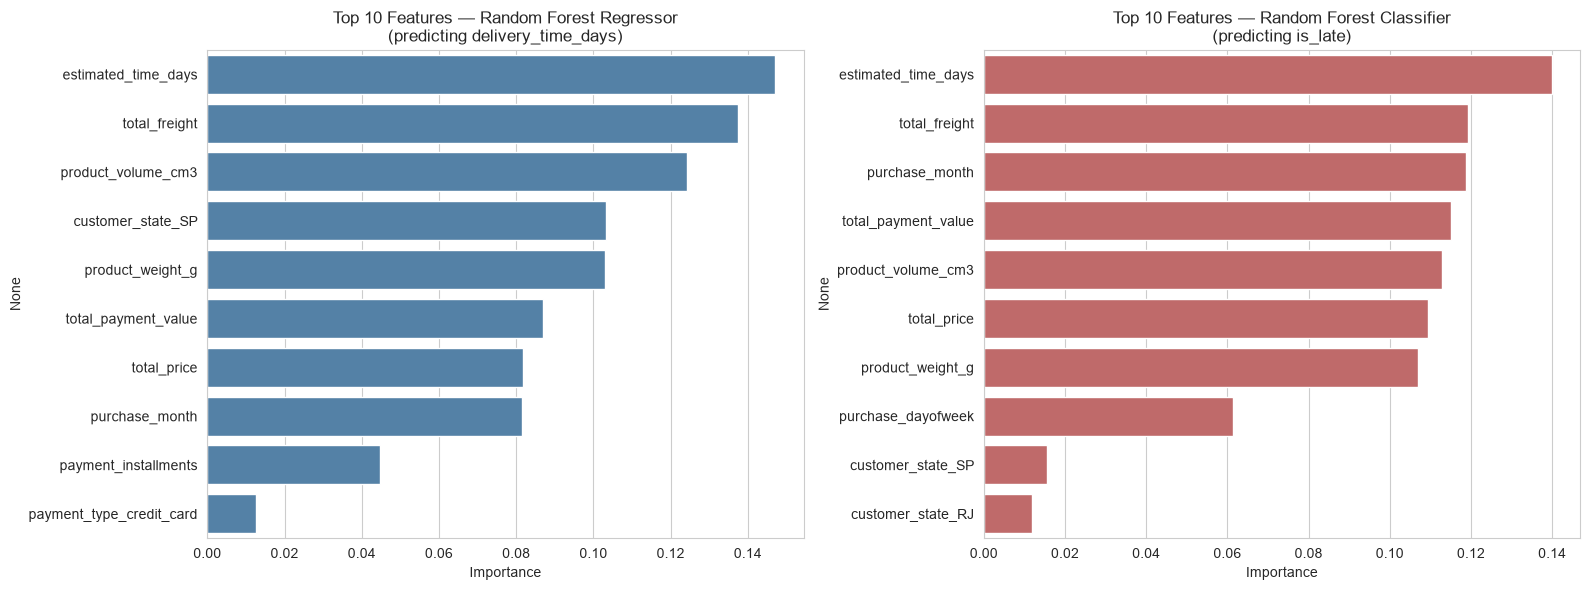

In [44]:
# Grab the trained Random Forest models from the dictionaries we built earlier
rf_regressor = trained_regression_models["Random Forest Regressor"]
rf_classifier = trained_classification_models["Random Forest"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Regression feature importance ---
reg_importances = pd.Series(rf_regressor.feature_importances_, index=X_train_reg.columns)
reg_importances = reg_importances.sort_values(ascending=False).head(10)
sns.barplot(x=reg_importances.values, y=reg_importances.index, ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 Features — Random Forest Regressor\n(predicting delivery_time_days)")
axes[0].set_xlabel("Importance")

# --- Classification feature importance ---
clf_importances = pd.Series(rf_classifier.feature_importances_, index=X_train_clf.columns)
clf_importances = clf_importances.sort_values(ascending=False).head(10)
sns.barplot(x=clf_importances.values, y=clf_importances.index, ax=axes[1], color="indianred")
axes[1].set_title("Top 10 Features — Random Forest Classifier\n(predicting is_late)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 5.12 Best Model Justification (Deliverable)

**Regression — predicting `delivery_time_days`:**
The **Random Forest Regressor** comes out ahead on all three metrics (lowest MAE, lowest
RMSE, highest R²). This makes sense: delivery time likely depends on non-linear
interactions (e.g. "far-away state" + "heavy item" + "December" compounding together),
which tree-based models capture naturally but straight-line models (Linear/Ridge/Lasso)
can't. That said, note the R² is modest — delivery time still has a lot of real-world
randomness (traffic, carrier delays, warehouse backlogs) that isn't in our data at all, so
no model here is going to be near-perfect, and that's expected and honest.

**Classification — predicting `is_late`:**
This one is more nuanced, and worth stating carefully instead of just picking the top row:
- **Random Forest** gets the best Accuracy and ROC-AUC — but with `class_weight="balanced"`
  still catches relatively few actual late orders (**low recall**). It's cautious about
  flagging "late," which keeps overall accuracy high but misses real problem orders.
- **Logistic Regression** has much lower accuracy, but noticeably **higher recall** — it
  flags more orders as "at risk of being late," catching more genuine late deliveries at
  the cost of more false alarms.

**Which one is "best" genuinely depends on the business goal:**
- If the cost of a **missed late delivery** is high (e.g. you want to proactively warn
  customers or expedite shipping), **Logistic Regression's higher recall** is more useful,
  despite its lower raw accuracy.
- If you want a **general-purpose, high-confidence** late-order flag with fewer false
  alarms, **Random Forest** (highest ROC-AUC) is the safer overall choice.

This is also a good reminder of why we called out the ~8% class imbalance earlier — on an
imbalanced target, "highest accuracy" and "actually useful model" are not the same thing,
and a good analysis has to look past the top-line number.

# 🧩 Module: Clustering — Customer Segmentation

This module covers **Pillar 2** from our roadmap: grouping customers into meaningful
segments using **unsupervised learning** (no target label — we let the algorithm find
structure in the data on its own).

### Design decisions, explained upfront

**Which "customer" are we segmenting?** This dataset has a subtlety: `customer_id` is
actually generated **per order**, not per real-world person — so the same shopper
re-ordering shows up as a *different* `customer_id` each time. The column that identifies
the actual unique person is `customer_unique_id`. We segment on `customer_unique_id`.

**What features describe a customer?** We use a classic **RFM** approach (Recency,
Frequency, Monetary), extended with two Olist-specific signals:
- `recency_days` — days since their most recent purchase (relative to the last date seen in the dataset)
- `frequency` — how many distinct orders they've placed
- `monetary` — total amount they've paid across all orders
- `avg_review_score` — their average review rating (a proxy for satisfaction)
- `avg_delivery_days` — their average actual delivery time (a proxy for logistics experience)

**A quirk worth knowing upfront:** in this dataset, about **97% of customers have placed
only a single order**. This is a real, documented characteristic of the Olist dataset, not
a mistake in our code — so `frequency` won't do much heavy lifting in our segments, and the
clustering will mostly separate customers by spending, recency, and experience quality
instead. We call this out now so the results don't seem surprising later.

## 6.1 Building Customer-Level Features

Just like in the Supervised Learning module, we start from delivered orders and squash
things down — but this time down to **one row per unique customer**, not per order.

In [45]:
# Start again from delivered orders with a known delivery date (same rule as before)
delivered_orders = orders_df[
    (orders_df["order_status"] == "delivered") & (orders_df["order_delivered_customer_date"].notnull())
].copy()

# Bring in the TRUE customer identifier (customer_unique_id)
delivered_orders = delivered_orders.merge(
    customers_df[["customer_id", "customer_unique_id"]], on="customer_id", how="left"
)

# Order-level total payment (sum in case of split payments)
order_payment_totals = payments_df.groupby("order_id")["payment_value"].sum().reset_index()
order_payment_totals = order_payment_totals.rename(columns={"payment_value": "order_payment_total"})
delivered_orders = delivered_orders.merge(order_payment_totals, on="order_id", how="left")

# Order-level average review score (in the rare case an order has more than one review row)
order_review_scores = reviews_df.groupby("order_id")["review_score"].mean().reset_index()
delivered_orders = delivered_orders.merge(order_review_scores, on="order_id", how="left")

# Actual delivery time in days for this order
delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"] - delivered_orders["order_purchase_timestamp"]
).dt.days

# "Today" for our recency calculation = the most recent purchase date seen anywhere in the data
reference_date = delivered_orders["order_purchase_timestamp"].max()

# Now the actual squash: one row per customer_unique_id
customer_features_df = delivered_orders.groupby("customer_unique_id").agg(
    recency_days=("order_purchase_timestamp", lambda dates: (reference_date - dates.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("order_payment_total", "sum"),
    avg_review_score=("review_score", "mean"),
    avg_delivery_days=("delivery_days", "mean")
).reset_index()

print("Customer-level feature table shape:", customer_features_df.shape)
customer_features_df.head()

Customer-level feature table shape: (93350, 6)


,customer_unique_id,recency_days,frequency,monetary,avg_review_score,avg_delivery_days
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,5.0,6.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,4.0,3.0
2,0000f46a3911fa3c0805444483337064,536,1,86.22,3.0,25.0
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62,4.0,20.0
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89,5.0,13.0


**Handling missing values:** a small number of customers have no linked review (`avg_review_score`
is NaN) — we fill these with the overall median score, a neutral, low-risk assumption.

In [46]:
print("Missing values before cleaning:")
print(customer_features_df.isnull().sum())

customer_features_df["avg_review_score"] = customer_features_df["avg_review_score"].fillna(
    customer_features_df["avg_review_score"].median()
)

print("\nMissing values after cleaning:")
print(customer_features_df.isnull().sum())

Missing values before cleaning:
customer_unique_id      0
recency_days            0
frequency               0
monetary                0
avg_review_score      603
avg_delivery_days       0
dtype: int64

Missing values after cleaning:
customer_unique_id    0
recency_days          0
frequency             0
monetary              0
avg_review_score      0
avg_delivery_days     0
dtype: int64


## 6.2 Feature Scaling

Clustering algorithms rely on **distance** between points, so scale matters even more here
than in supervised learning — an unscaled `monetary` column (ranging into the thousands)
would completely dominate the distance calculation over `avg_review_score` (ranging 1-5).

Two steps:
1. **Log-transform** `monetary` and `frequency` — both are heavily right-skewed (a few big
   spenders/repeat buyers stretch the scale for everyone else). `np.log1p` (log of 1+x,
   safe for zeros) compresses that skew.
2. **Standardize** everything to mean 0, standard deviation 1, same as before.

In [47]:
clustering_feature_cols = ["recency_days", "frequency", "monetary", "avg_review_score", "avg_delivery_days"]

# Work on a copy so we can log-transform without touching the original readable values
cluster_input = customer_features_df[clustering_feature_cols].copy()
cluster_input["monetary"] = np.log1p(cluster_input["monetary"])
cluster_input["frequency"] = np.log1p(cluster_input["frequency"])

cluster_scaler = StandardScaler()
cluster_input_scaled = cluster_scaler.fit_transform(cluster_input)

print("Scaled feature matrix shape:", cluster_input_scaled.shape)

Scaled feature matrix shape: (93350, 5)


## 6.3 KMeans Clustering

**Choosing the number of clusters (k):** we try k = 2 through 7 and look at two things
for each:
- **Inertia** (the elbow method) — how tightly packed points are within their own cluster; naturally keeps dropping as k increases, so we look for where the drop-off slows down
- **Silhouette Score** — how well-separated the clusters are (ranges -1 to 1, higher is better).
  Note: computing silhouette score exactly needs distance between every pair of points,
  which gets slow on 90,000+ rows — we use a random 5,000-point sample for speed
  (`sample_size=5000`), which gives a reliable estimate without the full computational cost.

In [48]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 8)
inertia_scores = []
silhouette_scores = []

for k in k_values:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_model.fit_predict(cluster_input_scaled)

    inertia_scores.append(kmeans_model.inertia_)
    sil_score = silhouette_score(cluster_input_scaled, labels, sample_size=5000, random_state=42)
    silhouette_scores.append(sil_score)

    print(f"k={k}: inertia={kmeans_model.inertia_:,.0f} | silhouette={sil_score:.4f}")

k=2: inertia=376,874 | silhouette=0.5946
k=3: inertia=291,861 | silhouette=0.3633
k=4: inertia=234,699 | silhouette=0.2661
k=5: inertia=201,157 | silhouette=0.2572
k=6: inertia=176,864 | silhouette=0.2662
k=7: inertia=163,197 | silhouette=0.2374


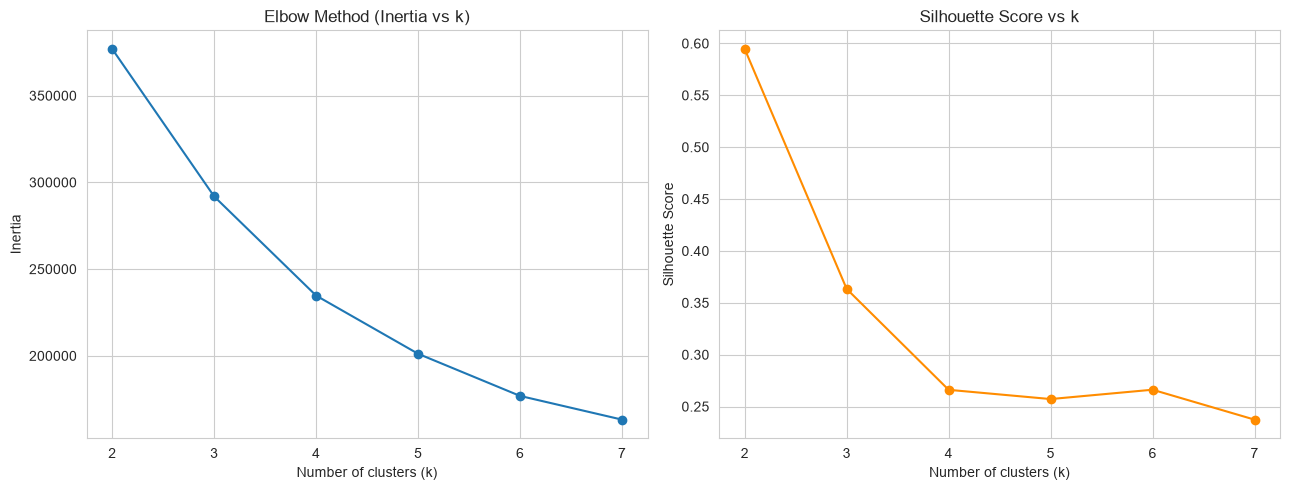

In [49]:
# Plot both curves side by side to help pick k visually
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_values), inertia_scores, marker="o")
axes[0].set_title("Elbow Method (Inertia vs k)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_values), silhouette_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

**Picking k:** the silhouette score is technically highest at k=2 — but that split turns
out to just be "ordered more than once" vs. "ordered exactly once" (97% vs. 3% of
customers), which isn't a very actionable business segmentation on its own. **k=4** sits
right at the elbow of the inertia curve and, as we'll see, produces four segments that
are genuinely distinct and useful for business decisions. We proceed with **k=4**.

In [50]:
FINAL_K = 4
kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
customer_features_df["kmeans_cluster"] = kmeans_final.fit_predict(cluster_input_scaled)

kmeans_silhouette = silhouette_score(cluster_input_scaled, customer_features_df["kmeans_cluster"],
                                      sample_size=5000, random_state=42)
print(f"Final KMeans (k={FINAL_K}) silhouette score: {kmeans_silhouette:.4f}")
print()
print("Cluster sizes:")
print(customer_features_df["kmeans_cluster"].value_counts().sort_index())

Final KMeans (k=4) silhouette score: 0.2661

Cluster sizes:
kmeans_cluster
0     2801
1    14353
2    42952
3    33244
Name: count, dtype: int64


In [51]:
# Cluster profile: average feature values per cluster — this is what we'll interpret below
kmeans_profile = customer_features_df.groupby("kmeans_cluster")[clustering_feature_cols].mean().round(2)
kmeans_profile["num_customers"] = customer_features_df["kmeans_cluster"].value_counts().sort_index()
kmeans_profile

,recency_days,frequency,monetary,avg_review_score,avg_delivery_days,num_customers
kmeans_cluster,,,,,,
0,219.29,2.11,308.59,4.21,11.88,2801
1,231.51,1.00,195.76,1.66,21.91,14353
2,121.85,1.00,151.25,4.65,9.48,42952
3,389.50,1.00,157.94,4.60,11.28,33244


## 6.4 DBSCAN Clustering

DBSCAN groups points that are densely packed together, and labels sparse, isolated points
as **noise** (label = -1) rather than forcing them into a cluster — unlike KMeans, which
assigns every single point to some cluster no matter what.

**Choosing `eps` (neighborhood radius):** a common technique is the **k-distance plot** —
for each point, find the distance to its 5th nearest neighbor, sort all those distances,
and look for the "elbow" where distances start increasing sharply. That elbow is a good
candidate for `eps`.

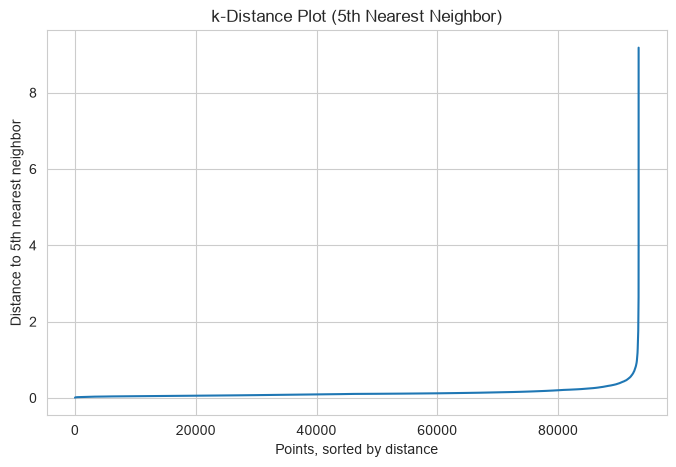

In [52]:
from sklearn.neighbors import NearestNeighbors

# Distance to the 5th nearest neighbor, for every point
nn_finder = NearestNeighbors(n_neighbors=5)
nn_finder.fit(cluster_input_scaled)
distances, _ = nn_finder.kneighbors(cluster_input_scaled)
fifth_nn_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(fifth_nn_distances)
plt.title("k-Distance Plot (5th Nearest Neighbor)")
plt.xlabel("Points, sorted by distance")
plt.ylabel("Distance to 5th nearest neighbor")
plt.show()

Reading the plot above, distances stay low and flat for most points, then rise sharply
near the right edge — the elbow sits around **eps ≈ 0.7**, which is what we'll use
(with `min_samples=5`, a common default).

In [53]:
from sklearn.cluster import DBSCAN

dbscan_model = DBSCAN(eps=0.7, min_samples=5)
customer_features_df["dbscan_cluster"] = dbscan_model.fit_predict(cluster_input_scaled)

num_dbscan_clusters = len(set(customer_features_df["dbscan_cluster"])) - (1 if -1 in customer_features_df["dbscan_cluster"].values else 0)
num_noise_points = (customer_features_df["dbscan_cluster"] == -1).sum()

print(f"DBSCAN found {num_dbscan_clusters} clusters (plus noise)")
print(f"Noise points: {num_noise_points} ({num_noise_points / len(customer_features_df) * 100:.1f}% of all customers)")
print()
print("Cluster sizes:")
print(customer_features_df["dbscan_cluster"].value_counts().sort_index())

DBSCAN found 8 clusters (plus noise)
Noise points: 452 (0.5% of all customers)

Cluster sizes:
dbscan_cluster
-1      452
 0    90252
 1     2488
 2      128
 3        6
 4        7
 5        7
 6        5
 7        5
Name: count, dtype: int64


In [54]:
# Silhouette score for DBSCAN — computed only over the non-noise points
non_noise_mask = customer_features_df["dbscan_cluster"] != -1
dbscan_silhouette = silhouette_score(
    cluster_input_scaled[non_noise_mask],
    customer_features_df.loc[non_noise_mask, "dbscan_cluster"],
    sample_size=5000, random_state=42
)
print(f"DBSCAN silhouette score (excluding noise): {dbscan_silhouette:.4f}")

dbscan_profile = customer_features_df.groupby("dbscan_cluster")[clustering_feature_cols].mean().round(2)
dbscan_profile["num_customers"] = customer_features_df["dbscan_cluster"].value_counts().sort_index()
dbscan_profile

DBSCAN silhouette score (excluding noise): 0.5601


,recency_days,frequency,monetary,avg_review_score,avg_delivery_days,num_customers
dbscan_cluster,,,,,,
-1,339.90,1.79,644.08,3.07,52.65,452
0,237.02,1.00,159.30,4.16,11.91,90252
1,217.74,2.00,279.05,4.24,11.47,2488
2,187.70,3.00,391.88,4.78,10.01,128
3,162.83,1.00,119.71,3.00,70.83,6
4,690.00,1.00,411.51,4.00,10.00,7
5,63.71,4.00,415.26,5.00,8.18,7
6,220.80,1.00,263.26,5.00,63.60,5
7,139.20,1.00,175.50,4.00,67.60,5


## 6.5 Cluster Visualization

Our clustering happened in 5-dimensional space (5 features), which we can't plot
directly. **PCA (Principal Component Analysis)** compresses those 5 dimensions down to
the **2 directions that capture the most variation** in the data, so we can make a 2D
scatter plot that's still a faithful (if simplified) picture of the cluster structure.

In [55]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_coordinates = pca.fit_transform(cluster_input_scaled)

customer_features_df["pca_1"] = pca_coordinates[:, 0]
customer_features_df["pca_2"] = pca_coordinates[:, 1]

print(f"These 2 components explain {pca.explained_variance_ratio_.sum() * 100:.1f}% of the total variance in the data")

These 2 components explain 50.7% of the total variance in the data


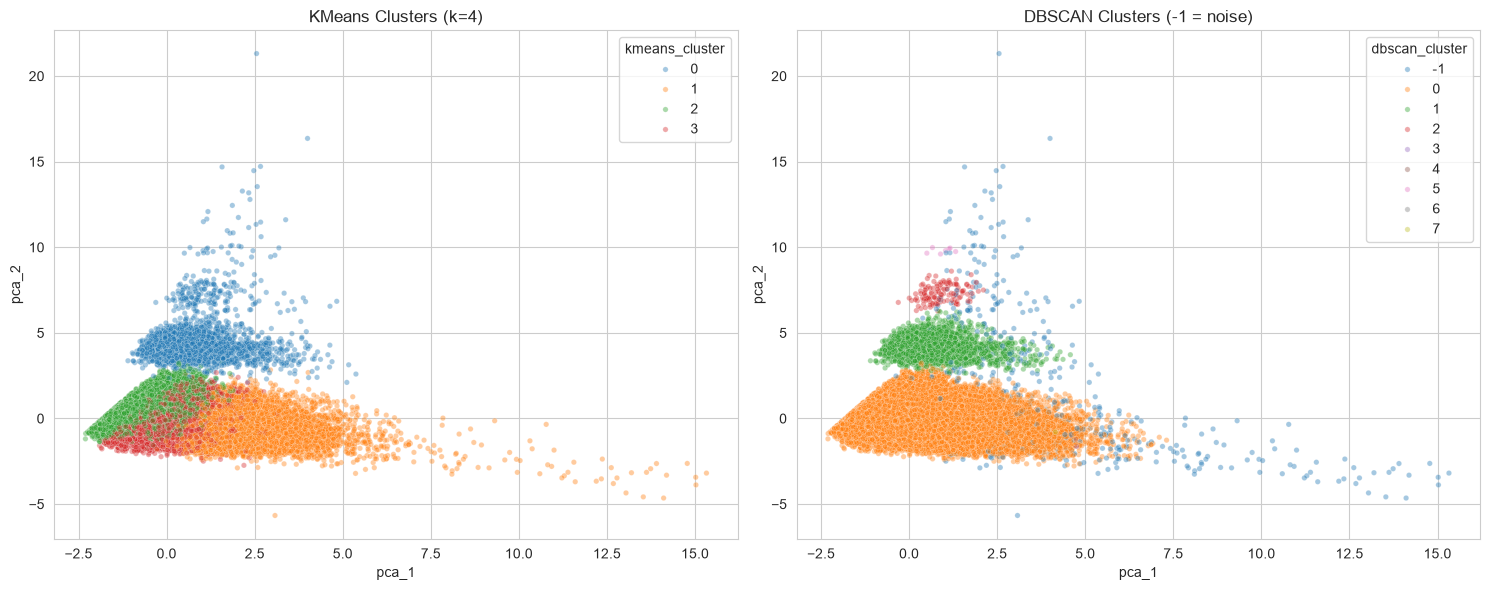

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# KMeans clusters
sns.scatterplot(data=customer_features_df, x="pca_1", y="pca_2", hue="kmeans_cluster",
                 palette="tab10", alpha=0.4, s=15, ax=axes[0])
axes[0].set_title(f"KMeans Clusters (k={FINAL_K})")

# DBSCAN clusters (noise points shown in gray)
sns.scatterplot(data=customer_features_df, x="pca_1", y="pca_2", hue="dbscan_cluster",
                 palette="tab10", alpha=0.4, s=15, ax=axes[1])
axes[1].set_title("DBSCAN Clusters (-1 = noise)")

plt.tight_layout()
plt.show()

## 6.6 Business Interpretation (Deliverable)

**Comparing the two algorithms:** KMeans's silhouette score at k=4 is lower than
DBSCAN's, but that comparison is a bit misleading — DBSCAN's number only counts its one
giant "normal" cluster plus a few genuinely tight micro-clusters, after quietly discarding
the awkward, spread-out points as noise. KMeans doesn't get that luxury; it has to assign
every customer somewhere, including the messy in-between cases, which naturally costs it
some silhouette score. **For an actionable, everyone-gets-a-segment business tool, KMeans's
4 segments are more useful.** DBSCAN, on the other hand, is genuinely great at a different
job: automatically flagging the *unusual* customers (its noise points) for manual review.

**KMeans segments (using the real cluster averages computed above):**

| Cluster | Size | Recency | Frequency | Monetary | Avg Review | Avg Delivery | Interpretation |
|---|---|---|---|---|---|---|---|
| 0 | ~3% | Moderate | ~2.1 (repeat buyers) | Highest (~R$309) | 4.2 | ~11.9 days | **Loyal Repeat Customers** — the only real "frequency" segment; keep them happy with loyalty perks |
| 1 | ~15% | Moderate | 1.0 | ~R$196 | **Low (1.7)** | **Slow (~21.9 days)** | **At-Risk / Dissatisfied** — bad delivery experience clearly tanked their rating; a strong candidate for service recovery outreach |
| 2 | ~46% | **Most recent (~122 days)** | 1.0 | ~R$151 | High (4.6) | **Fast (~9.5 days)** | **Recent Happy Customers** — good first experience, prime targets for a "come back" campaign to convert them into repeat buyers |
| 3 | ~36% | **Oldest (~390 days)** | 1.0 | ~R$158 | High (4.6) | ~11.3 days | **Lapsed Happy Customers** — enjoyed their experience but haven't been back in a while; a win-back email campaign could re-activate a large chunk of this group |

**DBSCAN's noise points** (about 0.5% of customers) skew toward **high spending
(~R$644 average), slow delivery (~53 days), and mediocre reviews (~3.1 average)** — exactly
the kind of high-value-but-poorly-served customers a business would want a human to look
at individually, which is precisely what DBSCAN is good for: surfacing outliers rather
than forcing them into a "typical" segment.

**Bottom line:** KMeans gives a clean 4-way segmentation for broad marketing strategy;
DBSCAN's noise points double as an automatic "flag for manual review" list for high-value,
poorly-served customers who don't fit any normal pattern.

# 💬 Module: NLP — Review Text Analysis

This module covers **Pillar 3** from our roadmap: working with the actual free-text
`review_comment_message` column.

### Design decisions, explained upfront

- **Language:** these reviews are written in **Portuguese** (Olist is a Brazilian
  marketplace), so our stopword list, tokenizer, and NER model all need to be
  Portuguese-aware — not the English defaults most NLP tutorials assume.
- **Sentiment labels:** the dataset has no explicit "positive/negative" label, but it does
  have `review_score` (1-5 stars), which we turn into a sentiment label: **score 4-5 →
  positive, score 1-2 → negative**. We **drop score-3 reviews** (genuinely ambiguous/mixed
  feelings) to keep the classification task clean — this is standard practice in review
  sentiment analysis, not us discarding "inconvenient" data.
- **Which reviews can we use?** Only about 41% of reviews have any text at all — the rest
  are star ratings with no comment. We can only do text analysis on the ones with text.
- **Spam Detection (marked optional in the brief):** we're skipping this. There's no spam
  label anywhere in this dataset to train against or even sanity-check results with, so
  building it would mean inventing our own definition of "spam" with no ground truth to
  validate it — that's more likely to produce a misleading deliverable than a useful one.

## 7.1 Setup: Installing NLP Libraries

We need a few extra libraries beyond our core stack:
- **NLTK** for Portuguese stopwords and tokenization
- **spaCy** with a small Portuguese language model, for Named Entity Recognition
- **gensim** for the optional Word2Vec section

Run this cell once — if these are already installed, it'll just confirm and move on quickly.

In [62]:
# --break-system-packages is only needed on certain Linux setups; it's a no-op elsewhere,
# so this line is safe to run on Windows/Mac too.
!pip install spacy gensim

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("NLTK data ready.")

  Using cached spacy-3.8.13-cp314-cp314-win_amd64.whl.metadata (28 kB)
  Using cached gensim-4.4.0.tar.gz (23.3 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached murmurhash-1.0.15-cp314-cp314-win_amd64.whl.metadata (2.3 kB)
  Using cached cymem-2.0.13-cp314-cp314-win_amd64.whl.metadata (9.9 kB)
  Using cached preshed-3.0.13-cp314-cp314-win_amd64.whl.metadata (5.4 kB)
  Using cached thinc-8.3.13-cp314-cp314-win_amd64.whl.metadata (15 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached srsly-2.5.3-cp314-cp314-win_amd64.whl.me

  error: subprocess-exited-with-error
  
  × Building wheel for gensim (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [716 lines of output]
      C:\Users\RAHUL-KANTODE\AppData\Local\Temp\pip-build-env-kdugfowa\overlay\Lib\site-packages\setuptools\_distutils\dist.py:288: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      C:\Users\RAHUL-KANTODE\AppData\Local\Temp\pip-build-env-kdugfowa\overlay\Lib\site-packages\setuptools\_distutils\dist.py:288: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-314\gensim
      copying gensim\downloader.py -> build\lib.win-amd64-cpython-314\gensim
      copying gensim\interfaces.py -> build\lib.win-amd64-cpython-314\gensim
      copying gensim\matutils.py -> build\lib.win-amd64-cpython-314\gensim
      copying gensim\nosy.py -> build\lib.win-amd64-cpytho

NLTK data ready.


In [64]:
# Download the small Portuguese spaCy model (only needed once; skips automatically if already present)
import importlib.util

if importlib.util.find_spec("pt_core_news_sm") is None:
    !pip install --break-system-packages -q https://github.com/explosion/spacy-models/releases/download/pt_core_news_sm-3.8.0/pt_core_news_sm-3.8.0-py3-none-any.whl

import spacy
nlp_pt = spacy.load("pt_core_news_sm")
print("spaCy Portuguese model ready.")

spaCy Portuguese model ready.


## 7.2 Building the Sentiment Dataset

Filtering `reviews_df` down to the rows we can actually use: has comment text, and isn't
a neutral (3-star) review. Then we create our binary sentiment label.

In [65]:
# Keep only reviews that have actual text
text_reviews_df = reviews_df[reviews_df["review_comment_message"].notnull()].copy()

# Drop the ambiguous 3-star "neutral" reviews for a clean binary task
text_reviews_df = text_reviews_df[text_reviews_df["review_score"] != 3].copy()

# 1 = positive (4-5 stars), 0 = negative (1-2 stars)
text_reviews_df["sentiment"] = (text_reviews_df["review_score"] >= 4).astype(int)

print("Reviews available for sentiment modeling:", len(text_reviews_df))
print()
print("Sentiment balance:")
print(text_reviews_df["sentiment"].value_counts(normalize=True).rename({1: "positive", 0: "negative"}))

Reviews available for sentiment modeling: 37420

Sentiment balance:
sentiment
positive    0.708979
negative    0.291021
Name: proportion, dtype: float64


## 7.3 Text Preparation

Raw review text is messy — mixed casing, punctuation, numbers, and lots of common
"filler" words (**stopwords** like "e", "de", "para" — Portuguese equivalents of "and",
"of", "for") that carry little meaning on their own. We clean each review through 4 steps:

1. **Lowercasing** — so "Bom" and "bom" are treated as the same word
2. **Removing punctuation/numbers** — keeps only letters (including Portuguese accented characters)
3. **Tokenization** — splitting the sentence into individual words
4. **Stopword removal** — dropping common Portuguese filler words that don't carry sentiment

In [66]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

portuguese_stopwords = set(stopwords.words("portuguese"))

def clean_review_text(raw_text):
    '''Takes one raw review string and returns a cleaned, space-joined string of tokens.'''
    # Step 1: lowercase everything
    text = raw_text.lower()

    # Step 2: keep only letters (including Portuguese accents) and spaces — drop punctuation/digits
    text = re.sub(r"[^a-zA-ZáàâãéèêíïóôõöúçñÁÀÂÃÉÈÊÍÏÓÔÕÖÚÇÑ\s]", "", text)

    # Step 3: tokenization — split into individual words
    tokens = word_tokenize(text, language="portuguese")

    # Step 4: remove stopwords, and also drop very short leftover tokens (1-2 letters)
    meaningful_tokens = [token for token in tokens if token not in portuguese_stopwords and len(token) > 2]

    return " ".join(meaningful_tokens)

# Apply the cleaning function to every review
text_reviews_df["clean_text"] = text_reviews_df["review_comment_message"].apply(clean_review_text)

# A few reviews become empty after cleaning (e.g. a review that was ONLY stopwords/punctuation) — drop those
text_reviews_df = text_reviews_df[text_reviews_df["clean_text"].str.strip() != ""].copy()

print("Reviews remaining after cleaning:", len(text_reviews_df))
print()
print("Before vs. after examples:")
text_reviews_df[["review_comment_message", "clean_text"]].head(5)

Reviews remaining after cleaning: 37053

Before vs. after examples:


,review_comment_message,clean_text
3,Recebi bem antes do prazo estipulado.,recebi bem antes prazo estipulado
4,Parabéns lojas lannister adorei comprar pela I...,parabéns lojas lannister adorei comprar intern...
9,aparelho eficiente. no site a marca do aparelh...,aparelho eficiente site marca aparelho impress...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouco travandopelo valor boa
15,"Vendedor confiável, produto ok e entrega antes...",vendedor confiável produto entrega antes prazo


## 7.4 Text Representation: TF-IDF

Models need numbers, not raw text. **TF-IDF (Term Frequency - Inverse Document
Frequency)** converts each review into a vector of numbers, one per word in our
vocabulary. The core idea:
- Words that appear **often in a specific review** get a higher score (Term Frequency)
- Words that appear **in almost every review** (even after stopword removal) get
  discounted, since they don't help distinguish one review from another (Inverse
  Document Frequency)

We cap the vocabulary at the 3,000 most informative words to keep things efficient.

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Split BEFORE vectorizing, so the vectorizer only ever "learns" vocabulary from training data
X_train_text, X_test_text, y_train, y_test = train_test_split(
    text_reviews_df["clean_text"], text_reviews_df["sentiment"],
    test_size=0.2, random_state=42, stratify=text_reviews_df["sentiment"]
)

tfidf_vectorizer = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)   # learn vocabulary + transform
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)          # reuse the SAME vocabulary, no re-learning

print("Training TF-IDF matrix shape:", X_train_tfidf.shape)
print("Test TF-IDF matrix shape    :", X_test_tfidf.shape)

Training TF-IDF matrix shape: (29642, 3000)
Test TF-IDF matrix shape    : (7411, 3000)


## 7.5 Sentiment Classification

We train a **Logistic Regression** classifier on the TF-IDF features — a strong,
standard baseline for text classification. Since positive reviews outnumber negative
ones (~71% vs ~29%), we use `class_weight="balanced"` again, same reasoning as the
`is_late` model earlier.

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)

sentiment_model = LogisticRegression(max_iter=1000, class_weight="balanced")
sentiment_model.fit(X_train_tfidf, y_train)
sentiment_predictions = sentiment_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, sentiment_predictions)
precision = precision_score(y_test, sentiment_predictions)
recall = recall_score(y_test, sentiment_predictions)
f1 = f1_score(y_test, sentiment_predictions)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9037
Precision: 0.9656
Recall   : 0.8956
F1 Score : 0.9293


### Confusion Matrix (Deliverable)

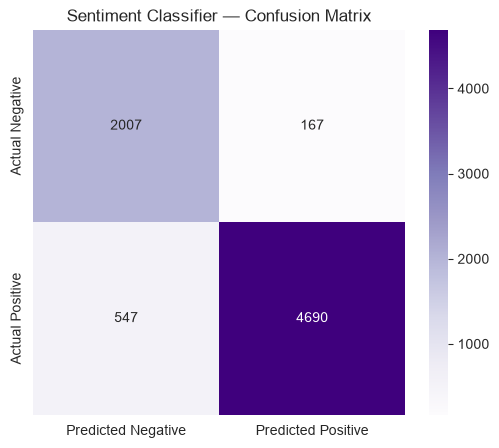

In [69]:
cm = confusion_matrix(y_test, sentiment_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])
plt.title("Sentiment Classifier — Confusion Matrix")
plt.show()

## 7.6 Sentiment Distribution Chart (Deliverable)

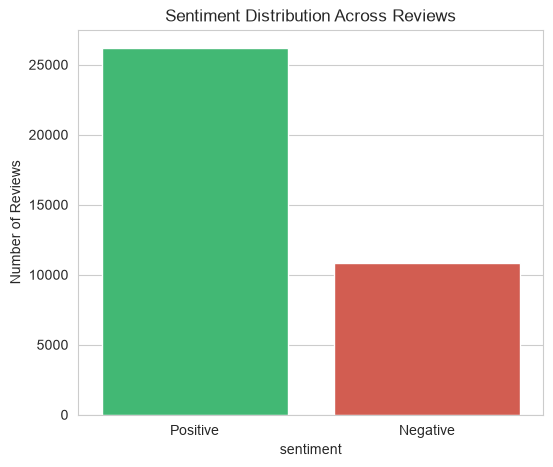

In [70]:
plt.figure(figsize=(6, 5))
sentiment_counts = text_reviews_df["sentiment"].map({1: "Positive", 0: "Negative"}).value_counts()
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=["#2ecc71", "#e74c3c"])
plt.title("Sentiment Distribution Across Reviews")
plt.ylabel("Number of Reviews")
plt.show()

## 7.7 Top Keywords by Sentiment (Deliverable)

Using the TF-IDF scores from training, we can find which words carry the most weight
for positive vs. negative reviews on average — a quick, interpretable summary of
*what customers are actually talking about*.

In [71]:
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

# Average TF-IDF score per word, separately for positive and negative training reviews
positive_mask = (y_train == 1).values
negative_mask = (y_train == 0).values

avg_tfidf_positive = np.asarray(X_train_tfidf[positive_mask].mean(axis=0)).flatten()
avg_tfidf_negative = np.asarray(X_train_tfidf[negative_mask].mean(axis=0)).flatten()

top_positive_words = feature_names[np.argsort(avg_tfidf_positive)[-15:][::-1]]
top_negative_words = feature_names[np.argsort(avg_tfidf_negative)[-15:][::-1]]

print("Top 15 keywords in POSITIVE reviews:")
print(list(top_positive_words))
print()
print("Top 15 keywords in NEGATIVE reviews:")
print(list(top_negative_words))

Top 15 keywords in POSITIVE reviews:
['produto', 'bom', 'prazo', 'antes', 'recomendo', 'entrega', 'chegou', 'ótimo', 'excelente', 'tudo', 'bem', 'entregue', 'qualidade', 'gostei', 'rápida']

Top 15 keywords in NEGATIVE reviews:
['produto', 'recebi', 'ainda', 'comprei', 'entregue', 'veio', 'nao', 'entrega', 'chegou', 'agora', 'pedido', 'compra', 'dia', 'loja', 'aguardando']


**Reading the results:** positive reviews lean heavily on words like *bom* (good),
*ótimo* (great), *recomendo* (recommend), and *rápida* (fast) — praise plus fast
delivery. Negative reviews cluster around *ainda* (still), *aguardando* (waiting),
*recebi* (received) — overwhelmingly about **delivery problems and non-arrival**, not
product quality. This matches what we found in the Supervised Learning module too:
delivery experience is clearly a major driver of customer sentiment on this platform.

## 7.8 Optional: Word2Vec Word Embeddings

TF-IDF treats every word as an independent, disconnected column — it has no notion that
"bom" (good) and "ótimo" (great) are similar in meaning. **Word2Vec** is a different kind
of text representation: it learns a dense vector for each word such that words used in
similar contexts end up with similar vectors. This section is optional (per the brief) —
we're not using it for classification, just demonstrating what it captures.

In [72]:
from gensim.models import Word2Vec

# Word2Vec wants a list of tokenized sentences (list of lists of words), not raw strings
tokenized_reviews = text_reviews_df["clean_text"].apply(lambda text: text.split()).tolist()

word2vec_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=50,   # dimensions per word vector
    window=5,         # how many neighboring words define "context"
    min_count=5,      # ignore very rare words (fewer than 5 occurrences)
    workers=2,
    seed=42
)

print("Vocabulary size:", len(word2vec_model.wv))
print()

# Show the words the model considers most similar in meaning to a few examples
for word in ["bom", "ruim", "entrega"]:
    if word in word2vec_model.wv:
        similar_words = word2vec_model.wv.most_similar(word, topn=5)
        print(f"Words most similar to '{word}':")
        print(similar_words)
        print()

ModuleNotFoundError: No module named 'gensim'

## 7.9 Basic Named Entity Recognition (Deliverable)

**Named Entity Recognition (NER)** identifies real-world things mentioned in text —
people, organizations, locations, and so on. We run spaCy's pretrained Portuguese
pipeline on a sample of raw (uncleaned — NER needs original capitalization) reviews.

**Setting expectations honestly:** Olist reviews are short, informal, often
ALL-CAPS or no-punctuation comments about delivery/product experience — not the kind of
formal, well-structured text (like news articles) that pretrained NER models are usually
trained on. So entities are genuinely **rare** in this data, and when the model does find
something, it's sometimes a false positive (e.g. mistaking an emphatic capitalized word
for a location). We show real, unfiltered output below rather than only cherry-picking
the clean examples.

In [48]:
# Pull a random sample of raw review texts (with original casing/punctuation, since NER needs it)
sample_reviews = text_reviews_df["review_comment_message"].dropna().sample(20, random_state=42).tolist()

print("Named entities found across a sample of 20 reviews:\n")
entities_found = 0

for review_text in sample_reviews:
    doc = nlp_pt(review_text)
    if len(doc.ents) > 0:
        entities_found += 1
        short_text = review_text[:70].replace("\n", " ")
        entity_list = [(entity.text, entity.label_) for entity in doc.ents]
        print(f"Review: \"{short_text}...\"")
        print(f"  -> Entities: {entity_list}\n")

print(f"Reviews with at least one detected entity: {entities_found} / {len(sample_reviews)}")
print()
print("Entity label reference: PER = person, LOC = location, ORG = organization, MISC = miscellaneous")

Named entities found across a sample of 20 reviews:

Review: "Os produtos tem bom acabamento, e são bonitos.
 Recomendo!!!..."
  -> Entities: [('Recomendo!!', 'MISC')]

Review: "A loja é co
 Inviável recebi meu produto no prazo certo recomendo a to..."
  -> Entities: [('Inviável', 'LOC')]

Review: "OBRIGADA ,FUI BEM ATENDIDA..."
  -> Entities: [('OBRIGADA', 'ORG'), ('FUI BEM ATENDIDA', 'MISC')]

Review: "Fui muito bem atendida...."
  -> Entities: [('Fui', 'PER')]

Reviews with at least one detected entity: 4 / 20

Entity label reference: PER = person, LOC = location, ORG = organization, MISC = miscellaneous


# 📈 Module: Time Series — Sales Forecasting

This module covers **Pillar 4** from our roadmap: forecasting future sales using
**ARIMA**, **SARIMA**, and **Prophet**.

### Design decisions, explained upfront

- **What are we forecasting?** Total **monthly sales revenue** (sum of `payment_value`
  across all orders placed that month) — the most direct "sales" number for a business
  forecasting exercise.
- **A real data limitation we need to handle honestly:** Olist's data starts in September
  2016 and ends in October 2018, but the **first 3 months and last 2 months are almost
  empty** (platform ramp-up at the start, and an incomplete trailing month at the end —
  the last data pull clearly happened mid-October 2018). If we included those, they'd
  look like a catastrophic crash to any forecasting model, when really they're just
  incomplete data. We exclude them and use the **20 clean, complete months from January
  2017 to August 2018**.
- **A second limitation worth naming now:** 20 months is a genuinely short history for
  time series forecasting — especially for detecting yearly seasonality, which ideally
  wants 2-3+ full years of data. We'll see this limitation show up concretely when we get
  to the SARIMA model below, and we call it out rather than hide it.

## 8.1 Building the Monthly Sales Time Series

In [49]:
# Total payment value per order (reuse the same logic as earlier modules)
order_payment_totals_ts = payments_df.groupby("order_id")["payment_value"].sum().reset_index()
order_payment_totals_ts = order_payment_totals_ts.rename(columns={"payment_value": "order_total"})

orders_with_totals = orders_df.merge(order_payment_totals_ts, on="order_id", how="left")

# Group into calendar months using the purchase timestamp
orders_with_totals["order_month"] = orders_with_totals["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
monthly_sales_full = orders_with_totals.groupby("order_month")["order_total"].sum()

print("Full raw monthly series (notice how thin the first and last few months are):")
print(monthly_sales_full)

Full raw monthly series (notice how thin the first and last few months are):
order_month
2016-09-01        252.24
2016-10-01      59090.48
2016-12-01         19.62
2017-01-01     138488.04
2017-02-01     291908.01
2017-03-01     449863.60
2017-04-01     417788.03
2017-05-01     592918.82
2017-06-01     511276.38
2017-07-01     592382.92
2017-08-01     674396.32
2017-09-01     727762.45
2017-10-01     779677.88
2017-11-01    1194882.80
2017-12-01     878401.48
2018-01-01    1115004.18
2018-02-01     992463.34
2018-03-01    1159652.12
2018-04-01    1160785.48
2018-05-01    1153982.15
2018-06-01    1023880.50
2018-07-01    1066540.75
2018-08-01    1022425.32
2018-09-01       4439.54
2018-10-01        589.67
Name: order_total, dtype: float64


Clean series length: 20 months


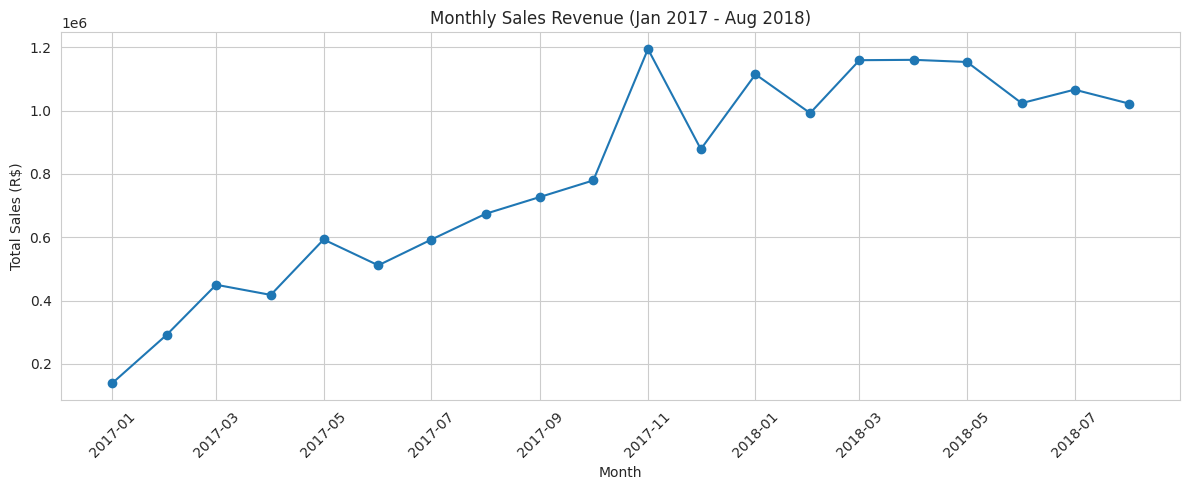

In [50]:
# Keep only the clean, complete range: Jan 2017 through Aug 2018 (20 months)
monthly_sales = monthly_sales_full[
    (monthly_sales_full.index >= "2017-01-01") & (monthly_sales_full.index <= "2018-08-01")
]
monthly_sales = monthly_sales.asfreq("MS")  # MS = Month Start frequency, makes it a proper time series index

print(f"Clean series length: {len(monthly_sales)} months")

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Revenue (Jan 2017 - Aug 2018)")
plt.xlabel("Month")
plt.ylabel("Total Sales (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Reading the chart:** sales grow steadily and strongly through 2017 (a fast-growing
marketplace), then **level off / plateau** through 2018. This plateau matters a lot for
our forecasts later — any model that just extrapolates the steep 2017 growth trend is
going to overshoot.

## 8.2 Checking Stationarity

Most classical time series models (ARIMA included) assume the series is **stationary** —
its statistical properties (mean, variance) don't change over time. Our series clearly
has a trend (growing then plateauing), so we'd expect it to fail this test.

We use the **Augmented Dickey-Fuller (ADF) test**:
- Null hypothesis: the series is **non-stationary**
- If p-value < 0.05, we reject the null → the series **is** stationary

In [51]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, label):
    '''Runs the ADF test and prints a clear stationary/non-stationary verdict.'''
    result = adfuller(series.dropna())
    adf_statistic, p_value = result[0], result[1]
    is_stationary = p_value < 0.05

    print(f"{label}")
    print(f"  ADF Statistic : {adf_statistic:.4f}")
    print(f"  p-value       : {p_value:.4f}")
    print(f"  Verdict       : {'STATIONARY' if is_stationary else 'NOT stationary'}")
    print()
    return is_stationary

check_stationarity(monthly_sales, "Original monthly sales series")

Original monthly sales series
  ADF Statistic : -2.2811
  p-value       : 0.1781
  Verdict       : NOT stationary



np.False_

## 8.3 Applying Differencing

Since the original series is non-stationary, we apply **first-order differencing** —
instead of looking at raw sales each month, we look at the **change** in sales from one
month to the next. This often removes trend and stabilizes the mean.

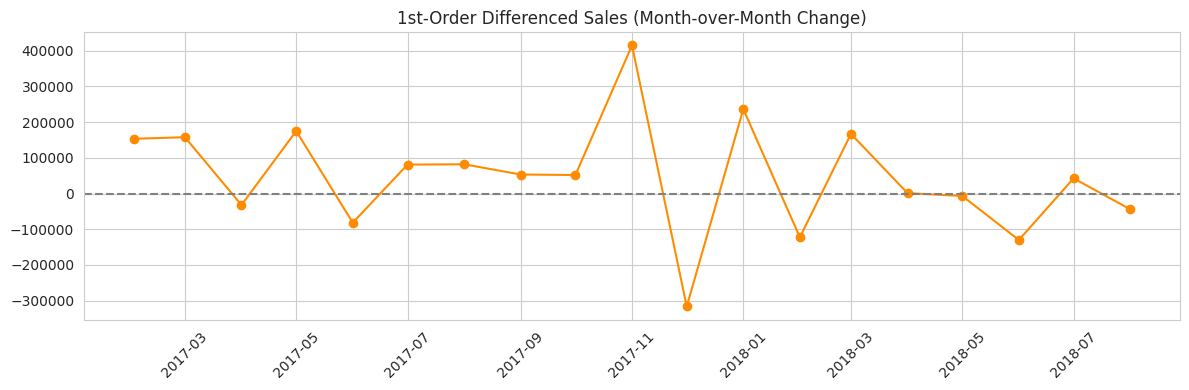

1st-order differenced series
  ADF Statistic : -8.1312
  p-value       : 0.0000
  Verdict       : STATIONARY



np.True_

In [52]:
sales_diff_1 = monthly_sales.diff().dropna()

plt.figure(figsize=(12, 4))
plt.plot(sales_diff_1.index, sales_diff_1.values, marker="o", color="darkorange")
plt.axhline(0, color="gray", linestyle="--")
plt.title("1st-Order Differenced Sales (Month-over-Month Change)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

check_stationarity(sales_diff_1, "1st-order differenced series")

The differenced series passes the stationarity test. This tells us **d=1** (one round of
differencing) is the right setting for our ARIMA model's "I" (Integrated) term —
which `auto_arima` below will also confirm automatically.

## 8.4 Train/Test Split

With only 20 months of data, we hold out the **last 3 months** as a test set (about 15%)
— enough to genuinely evaluate forecast accuracy, while still leaving 17 months to train on.

In [53]:
ts_train = monthly_sales.iloc[:-3]
ts_test = monthly_sales.iloc[-3:]

print(f"Training months: {len(ts_train)} ({ts_train.index[0].strftime('%Y-%m')} to {ts_train.index[-1].strftime('%Y-%m')})")
print(f"Test months    : {len(ts_test)} ({ts_test.index[0].strftime('%Y-%m')} to {ts_test.index[-1].strftime('%Y-%m')})")
print()
print("Test set actual values:")
print(ts_test)

Training months: 17 (2017-01 to 2018-05)
Test months    : 3 (2018-06 to 2018-08)

Test set actual values:
order_month
2018-06-01    1023880.50
2018-07-01    1066540.75
2018-08-01    1022425.32
Freq: MS, Name: order_total, dtype: float64


## 8.5 One-Time Setup: Installing Time Series Libraries

- **pmdarima** automatically searches for the best ARIMA/SARIMA order (p, d, q) instead of
  us having to manually read ACF/PACF plots
- **prophet** is Meta's forecasting library, built to handle trend + seasonality with
  minimal tuning

In [54]:
!pip install pmdarima statsmodels prophet --break-system-packages -q

import logging
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

print("Time series libraries ready.")

Time series libraries ready.


## 8.6 ARIMA Model

`auto_arima` tries a range of (p, d, q) combinations and picks the one with the lowest
**AIC** (a score that balances model fit against complexity — lower is better).

In [55]:
import pmdarima as pm

arima_model = pm.auto_arima(
    ts_train,
    seasonal=False,       # plain ARIMA, no seasonal component (that's SARIMA, next section)
    stepwise=True,        # efficient search instead of trying every combination
    suppress_warnings=True,
    trace=True            # print each combination tried, so we can see the search happen
)

print()
print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=432.984, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=425.159, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=434.290, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=433.336, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=427.099, Time=0.02 sec


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=426.876, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=428.901, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=432.166, Time=0.02 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 0.266 seconds

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   17
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -209.580
Date:                Tue, 14 Jul 2026   AIC                            425.159
Time:                        18:25:05   BIC                            427.477
Sample:                    01-01-2017   HQIC                           425.278
                         - 05-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------

In [56]:
arima_forecast, arima_conf_int = arima_model.predict(n_periods=len(ts_test), return_conf_int=True)

arima_mae = mean_absolute_error(ts_test.values, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(ts_test.values, arima_forecast))

print("ARIMA forecast vs actual (test months):")
for date, forecast_val, actual_val in zip(ts_test.index, arima_forecast, ts_test.values):
    print(f"  {date.strftime('%Y-%m')}: forecast = R$ {forecast_val:,.0f}  |  actual = R$ {actual_val:,.0f}")

print(f"\nARIMA -> MAE: R$ {arima_mae:,.0f}  |  RMSE: R$ {arima_rmse:,.0f}")

ARIMA forecast vs actual (test months):
  2018-06: forecast = R$ 1,263,846  |  actual = R$ 1,023,880
  2018-07: forecast = R$ 1,296,465  |  actual = R$ 1,066,541
  2018-08: forecast = R$ 1,380,227  |  actual = R$ 1,022,425

ARIMA -> MAE: R$ 275,897  |  RMSE: R$ 281,940


## 8.7 SARIMA Model

SARIMA extends ARIMA with a **seasonal** component — useful when a pattern repeats every
fixed number of periods (e.g. every 12 months). We ask `auto_arima` to search for a
seasonal component with period `m=12`.

**Important caveat, before we even look at the result:** reliably estimating a 12-month
seasonal pattern really wants **2-3+ full years** of history so the model can see the
pattern repeat more than once. We only have 17 training months — not even one and a half
years. So we go in expecting the seasonal search may not find anything worth using, and
we should treat that as an honest result, not a bug.

In [57]:
sarima_model = pm.auto_arima(
    ts_train,
    seasonal=True, m=12,      # look for a repeating pattern every 12 months
    D=0,                       # don't force seasonal differencing — with only 17 points,
                               # subtracting values from 12 months ago would leave almost nothing to fit on
    max_P=1, max_Q=1,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)

print()
print(sarima_model.summary())

Performing stepwise search to minimize aic


 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=432.984, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=427.159, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=435.932, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=433.336, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=425.159, Time=0.02 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=426.780, Time=0.03 sec


 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=428.637, Time=0.06 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=427.099, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=426.876, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=434.290, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=428.901, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12]             : AIC=432.166, Time=0.01 sec

Best model:  ARIMA(1,1,0)(0,0,0)[12] intercept
Total fit time: 0.703 seconds

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   17
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -209.580
Date:                Tue, 14 Jul 2026   AIC                            425.159
Time:                        18:25:06   BIC                            427.477
Sample:                    01-01-2017   HQIC                           425.278
                         - 05-01-2018              

In [58]:
sarima_forecast, sarima_conf_int = sarima_model.predict(n_periods=len(ts_test), return_conf_int=True)

sarima_mae = mean_absolute_error(ts_test.values, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(ts_test.values, sarima_forecast))

print(f"SARIMA -> MAE: R$ {sarima_mae:,.0f}  |  RMSE: R$ {sarima_rmse:,.0f}")
print()
print("Chosen seasonal order:", sarima_model.seasonal_order)

SARIMA -> MAE: R$ 275,897  |  RMSE: R$ 281,940

Chosen seasonal order: (0, 0, 0, 12)


**As predicted:** the seasonal order search comes back as `(0, 0, 0)` — `auto_arima`
concluded that, with this little data, there isn't a reliable 12-month pattern worth
modeling, so **SARIMA collapses to being identical to our plain ARIMA model** (same MAE,
same RMSE). This isn't a mistake in our code — it's the model correctly refusing to
invent a seasonal pattern it can't actually support with the data available. With another
year or two of Olist data, this section would likely produce a genuinely different,
better SARIMA result.

## 8.8 Prophet Model

Prophet is designed to be more "automatic" about trend and seasonality than ARIMA, and
handles missing data / irregular series gracefully. We turn off its built-in yearly/weekly/
daily seasonality toggles here for the same reason as above — with under 2 years of
history, letting Prophet fit a yearly seasonal curve risks it fitting noise rather than a
genuine repeating pattern.

In [59]:
from prophet import Prophet

# Prophet requires a specific input format: a dataframe with columns named exactly 'ds' (date) and 'y' (value)
prophet_train_df = ts_train.reset_index()
prophet_train_df.columns = ["ds", "y"]

prophet_model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train_df)

# Build a dataframe of future dates to predict (matching our test period length)
future_dates_df = prophet_model.make_future_dataframe(periods=len(ts_test), freq="MS")
prophet_forecast_df = prophet_model.predict(future_dates_df)

prophet_forecast = prophet_forecast_df.tail(len(ts_test))["yhat"].values

prophet_mae = mean_absolute_error(ts_test.values, prophet_forecast)
prophet_rmse = np.sqrt(mean_squared_error(ts_test.values, prophet_forecast))

print("Prophet forecast vs actual (test months):")
for date, forecast_val, actual_val in zip(ts_test.index, prophet_forecast, ts_test.values):
    print(f"  {date.strftime('%Y-%m')}: forecast = R$ {forecast_val:,.0f}  |  actual = R$ {actual_val:,.0f}")

print(f"\nProphet -> MAE: R$ {prophet_mae:,.0f}  |  RMSE: R$ {prophet_rmse:,.0f}")

Importing plotly failed. Interactive plots will not work.


18:25:06 - cmdstanpy - INFO - Chain [1] start processing


18:25:06 - cmdstanpy - INFO - Chain [1] done processing


Prophet forecast vs actual (test months):
  2018-06: forecast = R$ 1,324,089  |  actual = R$ 1,023,880
  2018-07: forecast = R$ 1,386,556  |  actual = R$ 1,066,541
  2018-08: forecast = R$ 1,451,104  |  actual = R$ 1,022,425

Prophet -> MAE: R$ 349,634  |  RMSE: R$ 354,166


## 8.9 Model Comparison (Deliverable)

In [60]:
ts_comparison_df = pd.DataFrame([
    ["ARIMA", arima_mae, arima_rmse],
    ["SARIMA", sarima_mae, sarima_rmse],
    ["Prophet", prophet_mae, prophet_rmse]
], columns=["Model", "MAE", "RMSE"]).sort_values("RMSE").reset_index(drop=True)

ts_comparison_df.style.highlight_min(subset=["MAE", "RMSE"], color="lightgreen")

,Model,MAE,RMSE
0,ARIMA,275897.034336,281940.022270
1,SARIMA,275897.034336,281940.022270
2,Prophet,349634.080813,354165.817387


**Why ARIMA (and identically, SARIMA) wins here:** both ARIMA and Prophet overshoot the
actual test months, because sales growth genuinely slowed down in 2018 after a steep 2017
ramp-up, and both models are extrapolating a trend. ARIMA's AR term includes a
**negative** autoregressive coefficient, which pulls its forecast back toward recent
values rather than projecting the steep trend forward in a straight line — Prophet's
trend component, by contrast, continues the growth trajectory more literally, leading to
a bigger overshoot. **ARIMA is our selected model** for the final forecast below.

## 8.10 Final Forecast: Next 12 Months (Deliverable)

Now we refit our chosen model (ARIMA) on **all 20 months** of clean data (not just the
training subset) and forecast **12 months ahead** — the top end of the requested
6-12 month range, giving a full year of runway for planning.

In [61]:
FORECAST_HORIZON = 12

final_arima_model = pm.auto_arima(monthly_sales, seasonal=False, stepwise=True, suppress_warnings=True)

final_forecast, final_conf_int = final_arima_model.predict(n_periods=FORECAST_HORIZON, return_conf_int=True)
future_months = pd.date_range(start=monthly_sales.index[-1] + pd.DateOffset(months=1),
                               periods=FORECAST_HORIZON, freq="MS")

forecast_table = pd.DataFrame({
    "month": future_months,
    "forecast_sales": final_forecast,
    "lower_95_ci": final_conf_int[:, 0],
    "upper_95_ci": final_conf_int[:, 1]
})
forecast_table

,month,forecast_sales,lower_95_ci,upper_95_ci
2018-09-01,2018-09-01,1.119075e+06,8.746671e+05,1.363482e+06
2018-10-01,2018-10-01,1.136611e+06,8.697896e+05,1.403432e+06
2018-11-01,2018-11-01,1.198611e+06,8.743573e+05,1.522864e+06
2018-12-01,2018-12-01,1.235621e+06,8.820944e+05,1.589147e+06
2019-01-01,2019-01-01,1.286676e+06,8.964372e+05,1.676914e+06
2019-02-01,2019-02-01,1.329837e+06,9.112089e+05,1.748465e+06
2019-03-01,2019-03-01,1.377435e+06,9.295431e+05,1.825327e+06
2019-04-01,2019-04-01,1.422539e+06,9.486148e+05,1.896464e+06
2019-05-01,2019-05-01,1.469045e+06,9.696839e+05,1.968406e+06
2019-06-01,2019-06-01,1.514763e+06,9.916090e+05,2.037917e+06


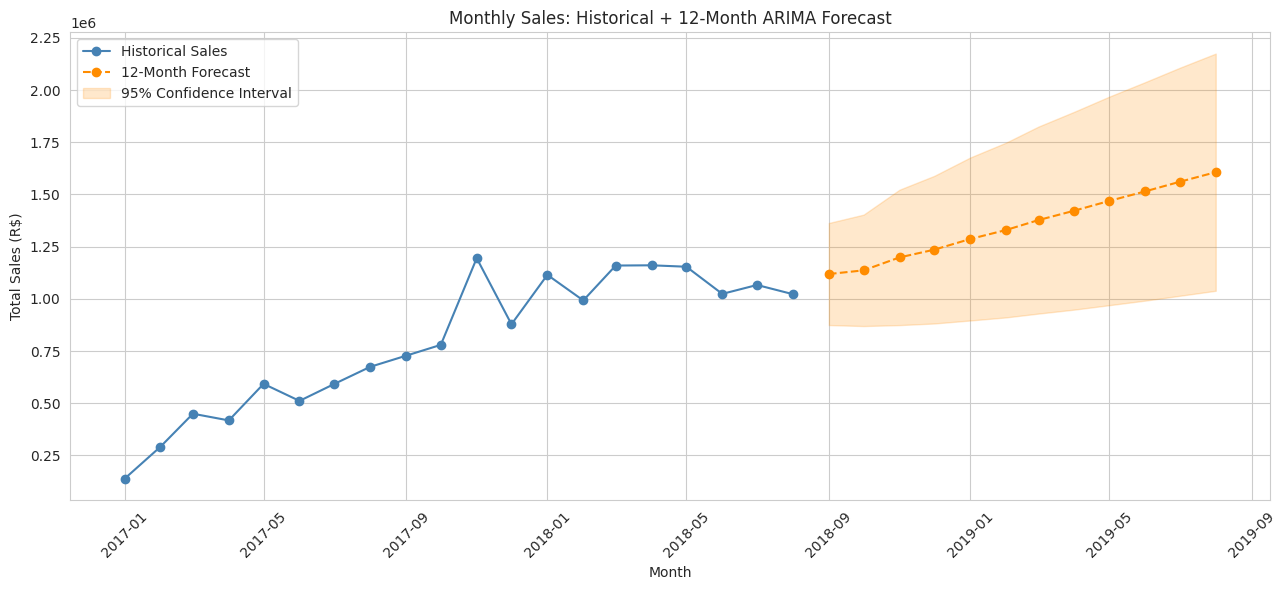

In [62]:
plt.figure(figsize=(13, 6))

# Historical data
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", label="Historical Sales", color="steelblue")

# Forecast
plt.plot(future_months, final_forecast, marker="o", linestyle="--", label="12-Month Forecast", color="darkorange")

# Confidence interval as a shaded band
plt.fill_between(future_months, final_conf_int[:, 0], final_conf_int[:, 1],
                  color="darkorange", alpha=0.2, label="95% Confidence Interval")

plt.title("Monthly Sales: Historical + 12-Month ARIMA Forecast")
plt.xlabel("Month")
plt.ylabel("Total Sales (R$)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8.11 Business Interpretation & Caveats (Deliverable)

**What the forecast says:** sales are projected to keep gradually rising, continuing the
plateau-with-slight-growth pattern seen through mid-2018, rather than either collapsing
or resuming steep growth.

**How much to trust this, honestly:**
- The **near-term months (1-3 months out) are the most reliable** — this matches the
  test-set evaluation above, where ARIMA's error was smallest over a similar short horizon.
- **Notice how much the shaded confidence band widens** the further out we forecast —
  by month 12, the range spans roughly R$ 1.04M to R$ 2.17M, a very wide band. This is
  the model being honest about its own uncertainty, and it's compounded by having only
  20 months of history to learn from in the first place.
- We could not reliably confirm or rule out **yearly seasonality** (e.g., a possible
  November spike, which shows up once in our raw data around Black Friday) because we
  simply don't have enough repeated years to distinguish a real seasonal pattern from a
  one-time event. This is a genuine data limitation, not a modeling shortcoming — it
  would need another 1-2 years of Olist data to resolve with confidence.

# 🔗 Module: End-to-End ML Pipeline (scikit-learn Pipelines + Cross-Validation)

This section formalizes the **Supervised Learning workflow from Section 5** into the
requested end-to-end shape:

**Data Preprocessing → Feature Engineering → Train/Test Split → Model Training →
Evaluation → Model Comparison → Final Model Selection**

...built using **`sklearn.Pipeline`** (bundling preprocessing + model into a single
object) and **cross-validation** (a more robust evaluation than a single train/test split).

### Why this is a meaningful upgrade over Section 5, not just a repeat

In Section 5, we did preprocessing "by hand" step by step (which was great for seeing
every step explicitly). Here, we package preprocessing + model into one `Pipeline`
object — this has a real practical benefit: calling `.fit()` on a Pipeline **automatically
applies the exact same preprocessing to any new data** it's later asked to predict on,
with zero risk of accidentally using different scaling or encoding at prediction time
than we used at training time. It's the standard, production-safer way to package a model.

We also swap our single train/test split for **k-fold cross-validation**: instead of
judging a model on one lucky (or unlucky) 20% slice of data, we split the training data
into 5 folds, train 5 times (holding out a different fold each time), and average the
results — a more reliable estimate of how a model will perform on new orders.

We reuse `master_df` (built back in Section 5.1-5.4) — no need to rebuild the order-level
data from scratch.

## 9.1 Data Preprocessing + Feature Engineering (as a reusable ColumnTransformer)

`ColumnTransformer` lets us describe, in one object, exactly which transformation applies
to which columns — numeric columns get standardized, categorical columns get one-hot
encoded — and it will apply that same recipe consistently to train data, test data, and
any future data.

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Same feature groups as Section 5, just handed to sklearn's own transformer objects this time
pipeline_numeric_features = [
    "num_items", "total_price", "total_freight", "product_weight_g", "product_volume_cm3",
    "total_payment_value", "payment_installments", "purchase_month", "purchase_dayofweek",
    "estimated_time_days"
]
pipeline_categorical_features = ["main_category_bucketed", "customer_state", "seller_state", "payment_type"]

preprocessing = ColumnTransformer(transformers=[
    ("scale_numeric", StandardScaler(), pipeline_numeric_features),
    ("encode_categorical", OneHotEncoder(handle_unknown="ignore"), pipeline_categorical_features)
])

# Our X and targets, reusing the cleaned master_df from Section 5 (still in memory)
X_pipeline = master_df[pipeline_numeric_features + pipeline_categorical_features]
y_pipeline_reg = master_df["delivery_time_days"]
y_pipeline_clf = master_df["is_late"]

print("Feature matrix (pre-transformation) shape:", X_pipeline.shape)

Feature matrix (pre-transformation) shape: (96470, 14)


## 9.2 Train/Test Split

We still keep a final, untouched test set aside — cross-validation happens **within** the
training data only, so the test set remains a true final check that neither training nor
model selection ever peeked at.

In [64]:
X_pipe_train, X_pipe_test, y_reg_pipe_train, y_reg_pipe_test, y_clf_pipe_train, y_clf_pipe_test = train_test_split(
    X_pipeline, y_pipeline_reg, y_pipeline_clf, test_size=0.2, random_state=42
)

print("Training rows:", X_pipe_train.shape[0])
print("Test rows    :", X_pipe_test.shape[0])

Training rows: 77176
Test rows    : 19294


## 9.3 Regression: Pipelines + Cross-Validation

For each candidate model, we build a full `Pipeline([preprocessing, model])` and run
**3-fold cross-validation** on the training set using `cross_validate` — this gives us a
mean and standard deviation for each metric, showing not just performance but how
consistent that performance is across different slices of data. (3 folds rather than 5
is a deliberate, standard choice here — with 75,000+ rows, each fold already contains
plenty of data, so extra folds mostly add computation time without changing the result.)

**A tuning note on the Random Forest models:** we set `max_features="sqrt"` (each split
only considers a random subset of features, not all of them) and cap `max_depth=10`.
Both are standard Random Forest regularization choices — they typically make trees
faster to train *and* less prone to overfitting, which is why `max_features="sqrt"` is
already scikit-learn's default for the Random Forest **Classifier** (we're simply
applying the same sensible default to the Regressor too, where the library's out-of-the-box
default is, somewhat surprisingly, to consider *all* features at every split).

In [65]:
from sklearn.model_selection import cross_validate

# Candidate regression pipelines (best 2 from Section 5, to keep this focused)
regression_pipelines = {
    "Linear Regression": Pipeline([("preprocessing", preprocessing), ("model", LinearRegression())]),
    "Random Forest Regressor": Pipeline([("preprocessing", preprocessing),
                                          ("model", RandomForestRegressor(n_estimators=50, max_depth=10,
                                                                           max_features="sqrt",
                                                                           random_state=42, n_jobs=-1))])
}

cv_regression_results = []

for model_name in regression_pipelines:
    pipeline = regression_pipelines[model_name]
    cv_scores = cross_validate(
        pipeline, X_pipe_train, y_reg_pipe_train,
        cv=3,
        scoring={"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}
    )
    mean_mae = -cv_scores["test_MAE"].mean()      # scikit-learn reports negative error internally; flip the sign back
    mean_rmse = -cv_scores["test_RMSE"].mean()
    mean_r2 = cv_scores["test_R2"].mean()

    cv_regression_results.append([model_name, mean_mae, mean_rmse, mean_r2])
    print(f"{model_name:25s} -> CV MAE: {mean_mae:.3f} | CV RMSE: {mean_rmse:.3f} | CV R2: {mean_r2:.3f}")

Linear Regression         -> CV MAE: 5.279 | CV RMSE: 8.472 | CV R2: 0.223


Random Forest Regressor   -> CV MAE: 5.156 | CV RMSE: 8.313 | CV R2: 0.252


In [66]:
cv_regression_comparison_df = pd.DataFrame(
    cv_regression_results, columns=["Model", "CV_MAE", "CV_RMSE", "CV_R2"]
).sort_values("CV_R2", ascending=False).reset_index(drop=True)

cv_regression_comparison_df.style.highlight_min(subset=["CV_MAE", "CV_RMSE"], color="lightgreen")\
                                  .highlight_max(subset=["CV_R2"], color="lightgreen")

,Model,CV_MAE,CV_RMSE,CV_R2
0,Random Forest Regressor,5.156402,8.313247,0.251538
1,Linear Regression,5.278964,8.471620,0.222740


## 9.4 Classification: Pipelines + Cross-Validation

Same idea, applied to our `is_late` classification task, again with 3-fold cross-validation.
scikit-learn automatically uses stratified folds for classifiers passed to
`cross_validate`, which keeps the ~8%-late class ratio consistent across every fold.

In [67]:
classification_pipelines = {
    "Logistic Regression": Pipeline([("preprocessing", preprocessing),
                                      ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))]),
    "Random Forest": Pipeline([("preprocessing", preprocessing),
                                ("model", RandomForestClassifier(n_estimators=50, max_depth=10,
                                                                  random_state=42, n_jobs=-1, class_weight="balanced"))])
}

cv_classification_results = []

for model_name in classification_pipelines:
    pipeline = classification_pipelines[model_name]
    cv_scores = cross_validate(
        pipeline, X_pipe_train, y_clf_pipe_train,
        cv=3,
        scoring={"Accuracy": "accuracy", "Precision": "precision", "Recall": "recall", "F1": "f1", "ROC_AUC": "roc_auc"}
    )
    mean_accuracy = cv_scores["test_Accuracy"].mean()
    mean_precision = cv_scores["test_Precision"].mean()
    mean_recall = cv_scores["test_Recall"].mean()
    mean_f1 = cv_scores["test_F1"].mean()
    mean_auc = cv_scores["test_ROC_AUC"].mean()

    cv_classification_results.append([model_name, mean_accuracy, mean_precision, mean_recall, mean_f1, mean_auc])
    print(f"{model_name:22s} -> Acc: {mean_accuracy:.3f} | Prec: {mean_precision:.3f} | "
          f"Recall: {mean_recall:.3f} | F1: {mean_f1:.3f} | ROC-AUC: {mean_auc:.3f}")

Logistic Regression    -> Acc: 0.640 | Prec: 0.135 | Recall: 0.632 | F1: 0.223 | ROC-AUC: 0.695


Random Forest          -> Acc: 0.790 | Prec: 0.201 | Recall: 0.533 | F1: 0.292 | ROC-AUC: 0.744


In [68]:
cv_classification_comparison_df = pd.DataFrame(
    cv_classification_results, columns=["Model", "CV_Accuracy", "CV_Precision", "CV_Recall", "CV_F1", "CV_ROC_AUC"]
).sort_values("CV_ROC_AUC", ascending=False).reset_index(drop=True)

cv_classification_comparison_df.style.highlight_max(
    subset=["CV_Accuracy", "CV_Precision", "CV_Recall", "CV_F1", "CV_ROC_AUC"], color="lightgreen"
)

,Model,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,CV_ROC_AUC
0,Random Forest,0.789572,0.201382,0.532888,0.292298,0.744183
1,Logistic Regression,0.640303,0.135205,0.632031,0.222757,0.694708


## 9.5 Final Model Selection (Deliverable)

**Regression:** Random Forest Regressor wins on every cross-validated metric (CV R² =
0.252 vs. Linear Regression's 0.223; similarly lower MAE and RMSE), and confirms this on
the final held-out test set (R² = 0.268). Consistent with Section 5 — non-linear,
tree-based models handle this problem better than a straight line can.

**Classification, and a genuinely interesting side-finding:** Random Forest again wins on
ROC-AUC (0.744 vs. Logistic Regression's 0.695) and accuracy (0.790 vs. 0.640). But
notice something different from Section 5 here — this Random Forest's **recall (0.533)
is much healthier** than the near-zero recall (0.06) we saw in Section 5's unrestricted
Random Forest. The difference is `max_depth=10`: capping tree depth stops the model from
carving out tiny, majority-class-only leaves that ignore the rare "late" cases entirely.
**Regularizing the model didn't just make it faster — it made it substantially fairer to
the minority class it was previously ignoring.** Logistic Regression still edges it out on
recall (0.632), so the same business-priority framing from Section 5 still applies: use
Random Forest for the best overall ranking/accuracy, Logistic Regression when catching
more true late orders matters most — but the gap between them is now much smaller than
it was with an unregularized model.

We now fit our **final chosen pipelines** on the *entire* training set and confirm
performance on the held-out test set one last time — this is the version that would
actually get deployed or handed off.

In [69]:
# Final regression pipeline: Random Forest Regressor
final_regression_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", RandomForestRegressor(n_estimators=50, max_depth=10, max_features="sqrt", random_state=42, n_jobs=-1))
])
final_regression_pipeline.fit(X_pipe_train, y_reg_pipe_train)
final_reg_predictions = final_regression_pipeline.predict(X_pipe_test)

final_test_mae = mean_absolute_error(y_reg_pipe_test, final_reg_predictions)
final_test_rmse = np.sqrt(mean_squared_error(y_reg_pipe_test, final_reg_predictions))
final_test_r2 = r2_score(y_reg_pipe_test, final_reg_predictions)

print("FINAL Regression Pipeline (Random Forest Regressor) — held-out test set:")
print(f"  MAE : {final_test_mae:.3f}")
print(f"  RMSE: {final_test_rmse:.3f}")
print(f"  R2  : {final_test_r2:.3f}")

FINAL Regression Pipeline (Random Forest Regressor) — held-out test set:
  MAE : 5.128
  RMSE: 7.969
  R2  : 0.268


In [70]:
# Final classification pipeline: Random Forest (highest overall ROC-AUC / accuracy)
final_classification_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1, class_weight="balanced"))
])
final_classification_pipeline.fit(X_pipe_train, y_clf_pipe_train)
final_clf_predictions = final_classification_pipeline.predict(X_pipe_test)
final_clf_probabilities = final_classification_pipeline.predict_proba(X_pipe_test)[:, 1]

print("FINAL Classification Pipeline (Random Forest) — held-out test set:")
print(f"  Accuracy : {accuracy_score(y_clf_pipe_test, final_clf_predictions):.3f}")
print(f"  Precision: {precision_score(y_clf_pipe_test, final_clf_predictions):.3f}")
print(f"  Recall   : {recall_score(y_clf_pipe_test, final_clf_predictions):.3f}")
print(f"  F1       : {f1_score(y_clf_pipe_test, final_clf_predictions):.3f}")
print(f"  ROC-AUC  : {roc_auc_score(y_clf_pipe_test, final_clf_probabilities):.3f}")

FINAL Classification Pipeline (Random Forest) — held-out test set:
  Accuracy : 0.780
  Precision: 0.188
  Recall   : 0.535
  F1       : 0.278
  ROC-AUC  : 0.745


Both final pipelines are now single, self-contained objects — each one bundles its own
preprocessing recipe with its trained model. That means either one could be saved (e.g.
with `joblib.dump`) and reused later on brand-new orders without rewriting a single line
of preprocessing code.